# Phase 2d - DiCE: Diverse Counterfactual Explanations

**DOLPH-X Pipeline | Master 2 MIAGE**

**Description:** Generates diverse counterfactual examples for each instance. For a student predicted as E-P-, DiCE finds minimal feature changes that would shift the prediction towards E+P+.

| Parameter | Value | Justification |
|---|---|---|
| Method | `genetic` | More faithful to real data than `random`; does not require dimensionality reduction unlike `kdtree` |
| Models | RF, XGBoost, Decision Tree | Consistent with SHAP and LIME |
| Target class | E+P+ (encoded 0) | Ideal profile to reach |
| Counterfactuals per instance | 3 | Sufficient diversity |
| Fixed features | Course context (name, year, public type) | Not modifiable by the student |
| Variable features | Behavioural features (submissions, activity) | Real actionable levers |

**Note:** DiCE failed to generate valid counterfactuals for most instances in this experiment due to the large feature-space distance between profiles and StandardScaler normalisation constraints. The `dice_explanations.csv` output is empty. This is documented as a known limitation.

**Input:** `evaluator.pkl`

**Output:** `outputs/dice_explanations.csv` (empty - see limitation note above)

## 1. Imports

In [5]:
from MLEvaluator import MLEvaluator
from XAIEvaluator import XAIEvaluator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import dice_ml
from dice_ml import Dice
warnings.filterwarnings("ignore")

## 2. Load Evaluator

In [6]:
evaluator = MLEvaluator.load("evaluator.pkl")

Evaluator loaded from 'evaluator.pkl'
  Available models: ['SVM', 'Logistic_Regression', 'Decision_Tree', 'KNN', 'Naive_Bayes', 'Random_Forest', 'Extra_Trees', 'Bagging', 'Gradient_Boosting', 'MLP', 'XGBoost']


## 3. DiCEEvaluator Class

In [17]:
# ============================================================
# CLASSE DiCE
# ============================================================
class DiCEEvaluator(XAIEvaluator):

    def __init__(self, ml_evaluator):
        """
        Initialise le DiCEEvaluator à partir d'un MLEvaluator déjà entraîné.

        Args:
            ml_evaluator : instance de MLEvaluator avec modèles déjà entraînés
        """
        # Récupérer tout depuis MLEvaluator
        super().__init__(ml_evaluator)
        
        # Tiroirs propres à DiCE
        self.dice_models     = {}
        self.counterfactuals = {}

        # Clipping des valeurs hors plage d'entraînement
        self.X_test_clipped = self.X_test.copy()
        for col in self.feature_names:
            col_min = self.X_train[col].min()
            col_max = self.X_train[col].max()
            self.X_test_clipped[col] = self.X_test_clipped[col].clip(col_min, col_max)


        # --------------------------------------------------------
        # Features fixes vs variables
        # DiCE a besoin de savoir quelles features il peut modifier
        # --------------------------------------------------------

        # Patterns des features FIXES
        fixed_patterns = [
            "Unnamed",
            "PUBLIC_",           # One-Hot de PUBLIC
            "ACADEMIC_Y_",       # One-Hot de ACADEMIC_Y
            "COURSE_NAME_",      # One-Hot de COURSE_NAME
            "TOTAL_STUDENTS",    # nombre d'étudiants
            "FIRST_",            # dates premières soumissions
            "LAST_",             # dates dernières soumissions
            "RANK_",             # classements
            "DIFF_RANKING_",     # différences de classement
        ]

        # Identifier les features fixes parmi les 184 colonnes
        self.fixed_features = [
            col for col in self.feature_names
            if any(col.startswith(p) or col == p for p in fixed_patterns)
        ]

        # Les features variables = toutes les autres
        self.variable_features = [
            col for col in self.feature_names
            if col not in self.fixed_features
        ]

        print(" DiCEEvaluator initialisé")
        print(f"   Modèles disponibles  : {list(self.trained_models.keys())}")
        print(f"   Features totales     : {len(self.feature_names)}")
        print(f"   Features fixes       : {len(self.fixed_features)}")
        print(f"   Features variables   : {len(self.variable_features)}")

    def setup_dice(self):
        """
        Prépare les objets DiCE pour chaque modèle entraîné.

        DiCE a besoin de :
        1. Un objet Data  → décrit les données et la cible
        2. Un objet Model → encapsule le modèle ML
        3. Un objet Dice  → combine Data + Model pour générer les contrefactuels
        """
        print("\n PRÉPARATION DE DiCE")
        print("=" * 60)

        # --------------------------------------------------------
        # Étape 1 — Préparer le dataset complet pour DiCE
        # DiCE a besoin des données X + y ensemble dans un DataFrame
        # --------------------------------------------------------
        train_data = self.X_train.copy()
        train_data["DIFFICULTY_encoded"] = self.y_train.values

        # --------------------------------------------------------
        # Étape 2 — Créer l'objet Data DiCE
        # Il décrit la structure du dataset :
        # - quelles colonnes sont des features
        # - quelle colonne est la cible
        # - quelles features sont continues vs catégorielles
        # --------------------------------------------------------
        dice_data = dice_ml.Data(
            dataframe=train_data,
            continuous_features=self.feature_names,  # features que DiCE peut modifier
            outcome_name="DIFFICULTY_encoded"             # colonne cible
        )

        print(f" Objet Data DiCE créé")
        print(f"   Features variables : {len(self.variable_features)}")

        # --------------------------------------------------------
        # Étape 3 — Créer un objet DiCE par modèle
        # --------------------------------------------------------

        # Modèles sélectionnés pour DiCE
        self.selected_models = ["Random_Forest", "XGBoost", "Decision_Tree"]

        for model_name, model in self.trained_models.items():
            if model_name not in self.selected_models:
                print(f" {model_name} ignoré")
                continue

            print(f"\n   Préparation DiCE pour {model_name}...")

            try:
                # Encapsuler le modèle sklearn dans un objet DiCE
                dice_model = dice_ml.Model(
                    model=model,
                    backend="sklearn",   # on utilise sklearn
                    model_type="classifier"
                )

                # Créer l'objet Dice qui combine Data + Model
                dice_exp = Dice(
                    dice_data,
                    dice_model,
                    method="genetic"      # choix de genetic au lieu de kdtree , random
                )

                # Sauvegarder
                self.dice_models[model_name] = {
                    "dice_exp"  : dice_exp,
                    "dice_data" : dice_data,
                    "dice_model": dice_model
                }

                print(f"   DiCE prêt pour {model_name}")

            except Exception as e:
                print(f"   Erreur pour {model_name} : {e}")
                continue

        print(f"\n DiCE préparé pour {len(self.dice_models)} modèles")
    

    def generate_counterfactuals(self, total_cfs=3):
        """
        Génère les contrefactuels pour chaque modèle
        et chaque échantillon sélectionné.

        Pour chaque élève prédit E-P- par exemple, DiCE génère
        3 scénarios alternatifs qui auraient mené à une prédiction
        différente.

        Args:
            total_cfs : nombre de contrefactuels à générer par élève
        """
        print("\n GÉNÉRATION DES CONTREFACTUELS")
        print("=" * 60)

        for model_name, dice_objects in self.dice_models.items():
            print(f"\n Modèle : {model_name}")
            print("-" * 40)

            dice_exp = dice_objects["dice_exp"]
            model_counterfactuals = {}

            for class_name, sample_indices in self.selected_samples.items():
                if not sample_indices:
                    print(f"    Aucun échantillon pour {class_name}")
                    continue

                print(f"\n   Classe : {class_name}")
                class_counterfactuals = []

                for sample_idx in sample_indices:
                    # Récupérer l'échantillon
                    #query_instance = self.X_test.iloc[[sample_idx]] avant test
                    query_instance = self.X_test_clipped.iloc[[sample_idx]]

                    # Filtre : on n'explique que les prédictions correctes
                    predicted  = int(self.trained_models[model_name].predict(
                                     self.X_test_clipped.iloc[[sample_idx]])[0])
                    true_label = int(self.y_test.iloc[sample_idx])
                    if predicted != true_label:
                        print(f'      ⚠Prédiction incorrecte → instance {sample_idx} ignorée')
                        continue

                    # Récupérer la classe actuelle de l'élève
                    current_class = int(self.y_test.iloc[sample_idx])
                    current_class_name = self.class_mapping.get(current_class, f"Classe {current_class}")

                    # E+P+ est encodé comme 1 → c'est notre classe cible
                    target_class = 0  # E+P+

                    # Si l'élève est déjà E+P+ → pas besoin de contrefactuel
                    if current_class == target_class:
                        print(f"      Échantillon {sample_idx} déjà E+P+ → ignoré")
                        continue


                    try:
                        # Générer les contrefactuels
                        # desired_class="opposite" → DiCE cherche
                        # n'importe quelle autre classe que la classe actuelle
                        cf_result = dice_exp.generate_counterfactuals(
                            query_instance,
                            total_CFs=total_cfs,
                            desired_class=target_class,
                            features_to_vary=self.variable_features,
                            proximity_weight=0.5,  
                            diversity_weight=1.0,   
                        )

                        # Extraire le DataFrame des contrefactuels
                        cf_df = cf_result.cf_examples_list[0].final_cfs_df

                        # Ajouter les infos de l'élève original
                        original_class = self.class_mapping.get(
                            int(self.y_test.iloc[sample_idx]),
                            f"Classe {self.y_test.iloc[sample_idx]}"
                        )

                        class_counterfactuals.append({
                            "sample_idx"    : sample_idx,
                            "original_class": original_class,
                            "query_instance": query_instance,
                            "counterfactuals": cf_df
                        })

                        print(f"Échantillon {sample_idx} : {total_cfs} contrefactuels générés")

                    except Exception as e:
                        print(f"Erreur échantillon {sample_idx} : {e}")
                        continue

                model_counterfactuals[class_name] = class_counterfactuals

            self.counterfactuals[model_name] = model_counterfactuals

        print(f"\n Contrefactuels générés pour {len(self.counterfactuals)} modèles")

    def plot_counterfactuals(self, model_name):
        """
        Visualise les contrefactuels pour un modèle donné.

        Pour chaque échantillon on génère :
        1. Tableau comparatif  → élève réel vs contrefactuels
        2. Bar chart           → features qui ont changé

        Args:
            model_name : nom du modèle à visualiser
        """
        if model_name not in self.counterfactuals:
            print(f" Pas de contrefactuels pour {model_name}")
            return

        print(f"\n VISUALISATION DiCE — {model_name}")
        print("=" * 60)

        for class_name, class_cfs in self.counterfactuals[model_name].items():
            if not class_cfs:
                continue

            print(f"\n   Classe : {class_name}")

            for cf_data in class_cfs:
                sample_idx     = cf_data["sample_idx"]
                original_class = cf_data["original_class"]
                query_instance = cf_data["query_instance"]
                cf_df          = cf_data["counterfactuals"]

                print(f"\n   Échantillon {sample_idx} — Classe originale : {original_class}")

                # --------------------------------------------------------
                # GRAPHIQUE 1 — Tableau comparatif
                # Montre les différences entre l'élève réel
                # et ses contrefactuels sur les features variables
                # --------------------------------------------------------
                try:
                    # Récupérer uniquement les features variables
                    # qui ont changé entre l'original et les contrefactuels
                    original_values = query_instance[self.variable_features].iloc[0]

                    # Identifier les features qui ont changé
                    changed_features = []
                    for feat in self.variable_features:
                        if feat in cf_df.columns:
                            # Vérifier si au moins un contrefactuel
                            # a une valeur différente de l'original
                            if any(cf_df[feat] != original_values[feat]):
                                changed_features.append(feat)

                    if not changed_features:
                        print(f" Aucune feature modifiée détectée")
                        continue

                    print(f"   Features modifiées : {len(changed_features)}")

                    # Construire le tableau comparatif
                    # Lignes = features modifiées
                    # Colonnes = Original + CF1 + CF2 + CF3
                    comparison_data = {"Original": original_values[changed_features]}

                    for i, (_, cf_row) in enumerate(cf_df.iterrows()):
                        # Récupérer la classe prédite du contrefactuel
                        cf_class = self.class_mapping.get(
                            int(cf_row["DIFFICULTY_encoded"]),
                            f"Classe {int(cf_row['DIFFICULTY_encoded'])}"
                        )
                        comparison_data[f"CF{i+1} ({cf_class})"] = cf_row[changed_features]

                    comparison_df = pd.DataFrame(comparison_data)

                    # Afficher le tableau
                    print(f"\n   Tableau comparatif :")
                    print(comparison_df.round(2).to_string())

                    # --------------------------------------------------------
                    # GRAPHIQUE 2 — Bar chart des changements
                    # Montre visuellement l'ampleur des changements
                    # pour chaque feature modifiée
                    # --------------------------------------------------------
                    n_cfs = len(cf_df)
                    fig, axes = plt.subplots(
                        1, n_cfs,
                        figsize=(6 * n_cfs, max(6, len(changed_features) * 0.4))
                    )

                    # Si un seul contrefactuel → axes n'est pas une liste
                    if n_cfs == 1:
                        axes = [axes]

                    colors = sns.color_palette("Set2", n_cfs)

                    for i, (_, cf_row) in enumerate(cf_df.iterrows()):
                        ax = axes[i]

                        cf_class = self.class_mapping.get(
                            int(cf_row["DIFFICULTY_encoded"]),
                            f"Classe {int(cf_row['DIFFICULTY_encoded'])}"
                        )

                        # Calculer les différences original → contrefactuel
                        original_vals = original_values[changed_features].values
                        cf_vals       = cf_row[changed_features].values
                        differences   = cf_vals - original_vals

                        # Couleur selon le sens du changement
                        bar_colors = [
                            "#2ecc71" if d > 0  # vert = augmentation
                            else "#e74c3c"       # rouge = diminution
                            for d in differences
                        ]

                        bars = ax.barh(
                            changed_features,
                            differences,
                            color=bar_colors,
                            alpha=0.8
                        )

                        # Ligne verticale à 0
                        ax.axvline(x=0, color="black", linewidth=0.8)

                        ax.set_title(
                            f"Contrefactuel {i+1}\n"
                            f"{original_class} → {cf_class}",
                            fontsize=11,
                            fontweight="bold"
                        )
                        ax.set_xlabel("Changement par rapport à l'original")
                        ax.grid(True, alpha=0.3)

                        # Ajouter les valeurs sur les barres
                        for bar, diff, orig, cf_val in zip(
                            bars, differences, original_vals, cf_vals
                        ):
                            ax.text(
                                bar.get_width() + (max(abs(differences)) * 0.02),
                                bar.get_y() + bar.get_height() / 2,
                                f"{orig:.1f} → {cf_val:.1f}",
                                va="center",
                                fontsize=8
                            )

                    plt.suptitle(
                        f"{model_name} — Échantillon {sample_idx}\n"
                        f"Classe originale : {original_class}",
                        fontsize=13,
                        fontweight="bold"
                    )
                    plt.tight_layout()
                    plt.show()

                except Exception as e:
                    print(f"Erreur visualisation : {e}")
                    continue

    def print_summary(self):
        """
        Affiche un résumé des contrefactuels générés :
        - Combien de contrefactuels par classe et par modèle
        - Quelles features ont été le plus souvent modifiées
        - L'ampleur moyenne des changements
        """
        print("\n" + "=" * 70)
        print(" RÉSUMÉ DES CONTREFACTUELS DiCE")
        print("=" * 70)

        for model_name, model_cfs in self.counterfactuals.items():
            print(f"\n {model_name.upper().replace('_', ' ')}")
            print("-" * 60)

            # Compter les contrefactuels générés
            total_cfs = sum(
                len(class_cfs)
                for class_cfs in model_cfs.values()
            )
            print(f"   Total échantillons expliqués : {total_cfs}")

            # Analyser les features les plus souvent modifiées
            all_changed_features = {}

            for class_name, class_cfs in model_cfs.items():
                print(f"\n   Classe {class_name} :")

                for cf_data in class_cfs:
                    query_instance = cf_data["query_instance"]
                    cf_df          = cf_data["counterfactuals"]
                    original_class = cf_data["original_class"]

                    original_values = query_instance[
                        self.variable_features
                    ].iloc[0]

                    # Compter les features modifiées
                    for feat in self.variable_features:
                        if feat in cf_df.columns:
                            if any(cf_df[feat] != original_values[feat]):
                                all_changed_features[feat] = (
                                    all_changed_features.get(feat, 0) + 1
                                )

                    # Afficher les classes cibles atteintes
                    if "DIFFICULTY_encoded" in cf_df.columns:
                        target_classes = [
                            self.class_mapping.get(
                                int(row["DIFFICULTY_encoded"]),
                                f"Classe {int(row['DIFFICULTY_encoded'])}"
                            )
                            for _, row in cf_df.iterrows()
                        ]
                        print(
                            f"      Échantillon {cf_data['sample_idx']} "
                            f"({original_class}) → {target_classes}"
                        )

            # Top 5 features les plus souvent modifiées
            if all_changed_features:
                top_features = sorted(
                    all_changed_features.items(),
                    key=lambda x: x[1],
                    reverse=True
                )[:5]

                print(f"\n   Top 5 features les plus modifiées :")
                for feat, count in top_features:
                    print(f"      {feat:40} : modifiée {count} fois")

    def export(self, filename='outputs/dice_explanations.csv'):
        """
        Exporte les contrefactuels DiCE en CSV.
        Format : une ligne par (modèle, instance, contrefactuel, feature modifiée).
        Ce fichier sera fusionné avec LIME, SHAP et MC-LIME pour la Phase 3.
        """
        import os
        os.makedirs('outputs', exist_ok=True)
        rows = []
    
        for model_name, model_cfs in self.counterfactuals.items():
            for class_name, class_cfs in model_cfs.items():
                for cf_data in class_cfs:
                    sample_idx      = cf_data['sample_idx']
                    original_class  = cf_data['original_class']
                    query_instance  = cf_data['query_instance']
                    cf_df           = cf_data['counterfactuals']
                    original_values = query_instance[self.variable_features].iloc[0]
    
                    for cf_idx, (_, cf_row) in enumerate(cf_df.iterrows()):
                        cf_class = self.class_mapping.get(
                            int(cf_row['DIFFICULTY_encoded']), '?'
                        )
                        base = {
                            'model'          : model_name,
                            'instance_id'    : sample_idx,
                            'profil_reel'    : class_name,
                            'vrai_label'     : original_class,
                            'cf_index'       : cf_idx + 1,
                            'cf_classe_cible': cf_class,
                            'methode'        : 'DiCE',
                        }
                        for feat in self.variable_features:
                            if feat in cf_df.columns:
                                orig_val = float(original_values[feat])
                                cf_val   = float(cf_row[feat])
                                delta    = cf_val - orig_val
                                if abs(delta) > 1e-6:
                                    row = base.copy()
                                    row['feature']        = feat
                                    row['valeur_origine'] = round(orig_val, 4)
                                    row['valeur_cf']      = round(cf_val, 4)
                                    row['delta']          = round(delta, 4)
                                    row['abs_delta']      = round(abs(delta), 4)
                                    rows.append(row)
    
        df = pd.DataFrame(rows) if rows else pd.DataFrame()
        df.to_csv(filename, index=False)
        print(f'✓ Export : {filename}')
        if len(rows) > 0:
            print(f'  {len(rows)} lignes | {df["instance_id"].nunique()} instances')
        return df

    # MÉTHODE PRINCIPALE
    def run(self):
        """
        Lance tout le pipeline DiCE dans l'ordre :

        1. Sélectionner les échantillons par classe
        2. Préparer DiCE pour chaque modèle
        3. Générer les contrefactuels
        4. Visualiser les résultats
        5. Afficher le résumé
        """
        print(" LANCEMENT DU PIPELINE DiCE")
        print("=" * 70)

        # Étape 1 — Sélection des échantillons
        self.select_samples()

        # Étape 2 — Préparation de DiCE
        self.setup_dice()

        # Étape 3 — Génération des contrefactuels
        self.generate_counterfactuals(total_cfs=3)

        # Étape 4 — Visualisation par modèle
        print("\n VISUALISATION DES CONTREFACTUELS")
        print("=" * 70)
        for model_name in self.counterfactuals.keys():
            self.plot_counterfactuals(model_name)

        # Étape 5 — Résumé
        self.print_summary()

        # Étape 6 — Export
        self.export()
        
        print("\n PIPELINE DiCE TERMINÉ !")

## 4. Execution

 DiCEEvaluator initialisé
   Modèles disponibles  : ['Decision_Tree', 'Random_Forest', 'XGBoost']
   Features totales     : 170
   Features fixes       : 144
   Features variables   : 26
 LANCEMENT DU PIPELINE DiCE

SELECTING REPRESENTATIVE INSTANCES
Class mapping: {0: 'E+P+', 1: 'E+P-', 2: 'E-P+', 3: 'E-P-'}

E+P+: 6 consensus / 7 total
  -> 4 instances selected

E+P-: 2 consensus / 4 total
  -> 2 instance(s) available (minority profile)

E-P+: 9 consensus / 9 total
  -> 4 instances selected

E-P-: 3 consensus / 6 total
  -> 3 instance(s) available (minority profile)

Total selected: 13 instances

 PRÉPARATION DE DiCE
 Objet Data DiCE créé
   Features variables : 26

   Préparation DiCE pour Decision_Tree...
   DiCE prêt pour Decision_Tree

   Préparation DiCE pour Random_Forest...
   DiCE prêt pour Random_Forest

   Préparation DiCE pour XGBoost...
   DiCE prêt pour XGBoost

 DiCE préparé pour 3 modèles

 GÉNÉRATION DES CONTREFACTUELS

 Modèle : Decision_Tree
------------------------

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  2.00it/s]


Échantillon 14 : 3 contrefactuels générés


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  2.96it/s]


Échantillon 24 : 3 contrefactuels générés

   Classe : E-P+
      ⚠Prédiction incorrecte → instance 15 ignorée
      ⚠Prédiction incorrecte → instance 1 ignorée


...

Échantillon 7 : 3 contrefactuels générés


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.83it/s]


Échantillon 18 : 3 contrefactuels générés


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.53it/s]


Échantillon 22 : 3 contrefactuels générés

 Contrefactuels générés pour 3 modèles

 VISUALISATION DES CONTREFACTUELS

 VISUALISATION DiCE — Decision_Tree

   Classe : E+P-

   Échantillon 14 — Classe originale : E+P-
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION       -1.00       -0.60       -1.30       -1.30
COURSE_ACCESS_MINUTES          -0.15       -1.17       -1.17       -1.17
COURSE_INTERACTIONS            -0.46       -0.32       -0.20       -0.20
T_EXE_SUBMISSION_COUNT         -0.19       -0.10       -0.39       -0.39
RATING_S1Q1                    -0.08        0.81       -0.08       -0.08
S1Q1_EXE_SUBMISSION_COUNT       1.09       -0.87       -0.38       -1.36
RATING_S2Q1                     0.46       -0.00        0.76        0.76
S2Q1_EXE_SUBMISSION_COUNT       0.04       -0.30       -0.64       -0.30
RATING_S3Q1                     0.82       -1.82       -1.82       -1.82
S

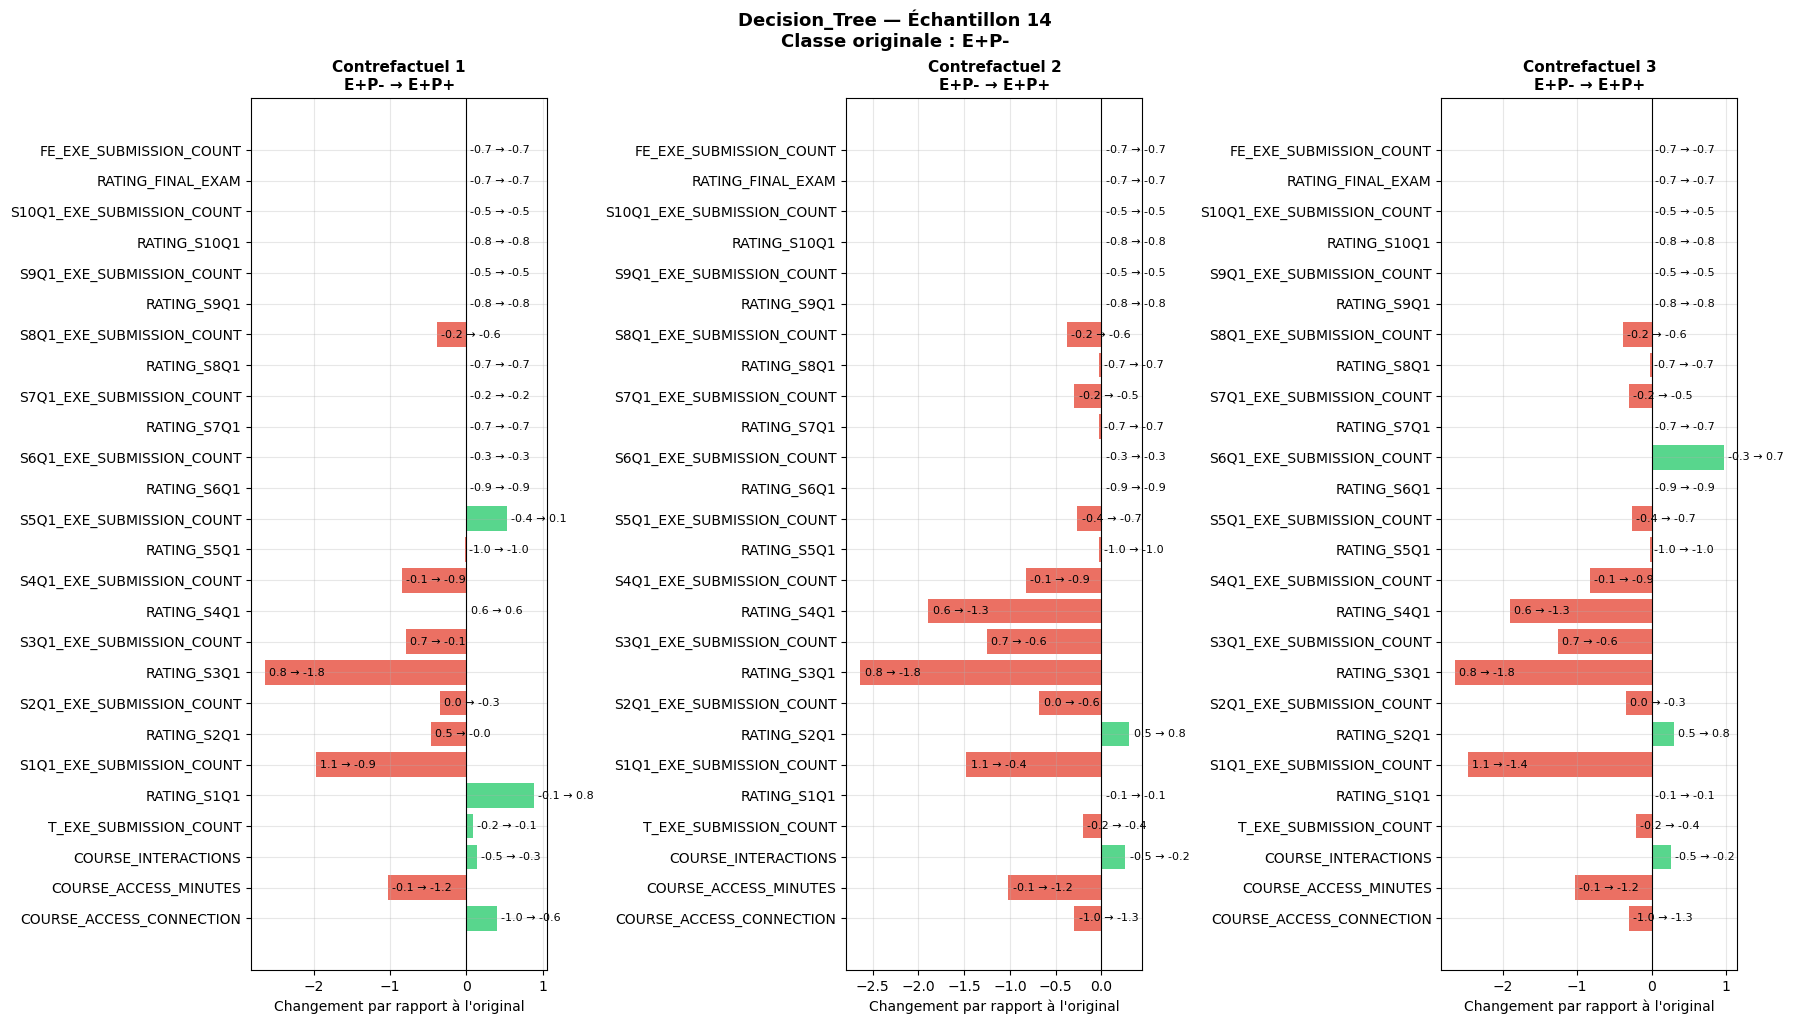


   Échantillon 24 — Classe originale : E+P-
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION       -0.70       -1.30       -1.30       -1.30
COURSE_ACCESS_MINUTES          -1.16       -1.17       -0.92       -1.17
COURSE_INTERACTIONS            -1.11       -1.20       -1.20       -0.40
T_EXE_SUBMISSION_COUNT         -0.64       -0.02       -0.19       -0.02
RATING_S1Q1                    -4.49       -4.49       -4.49       -4.49
S1Q1_EXE_SUBMISSION_COUNT      -1.36       -1.36       -1.36        0.60
RATING_S2Q1                    -2.25        0.16        0.16       -2.25
S2Q1_EXE_SUBMISSION_COUNT      -0.64       -0.64       -0.64       -0.64
RATING_S3Q1                    -1.82       -1.82       -1.82        0.29
S3Q1_EXE_SUBMISSION_COUNT      -0.59       -0.59       -0.59       -0.59
RATING_S4Q1                    -1.26        0.87        0.87       -1.26
S4Q1_EXE_SUBMISSION_COUNT  

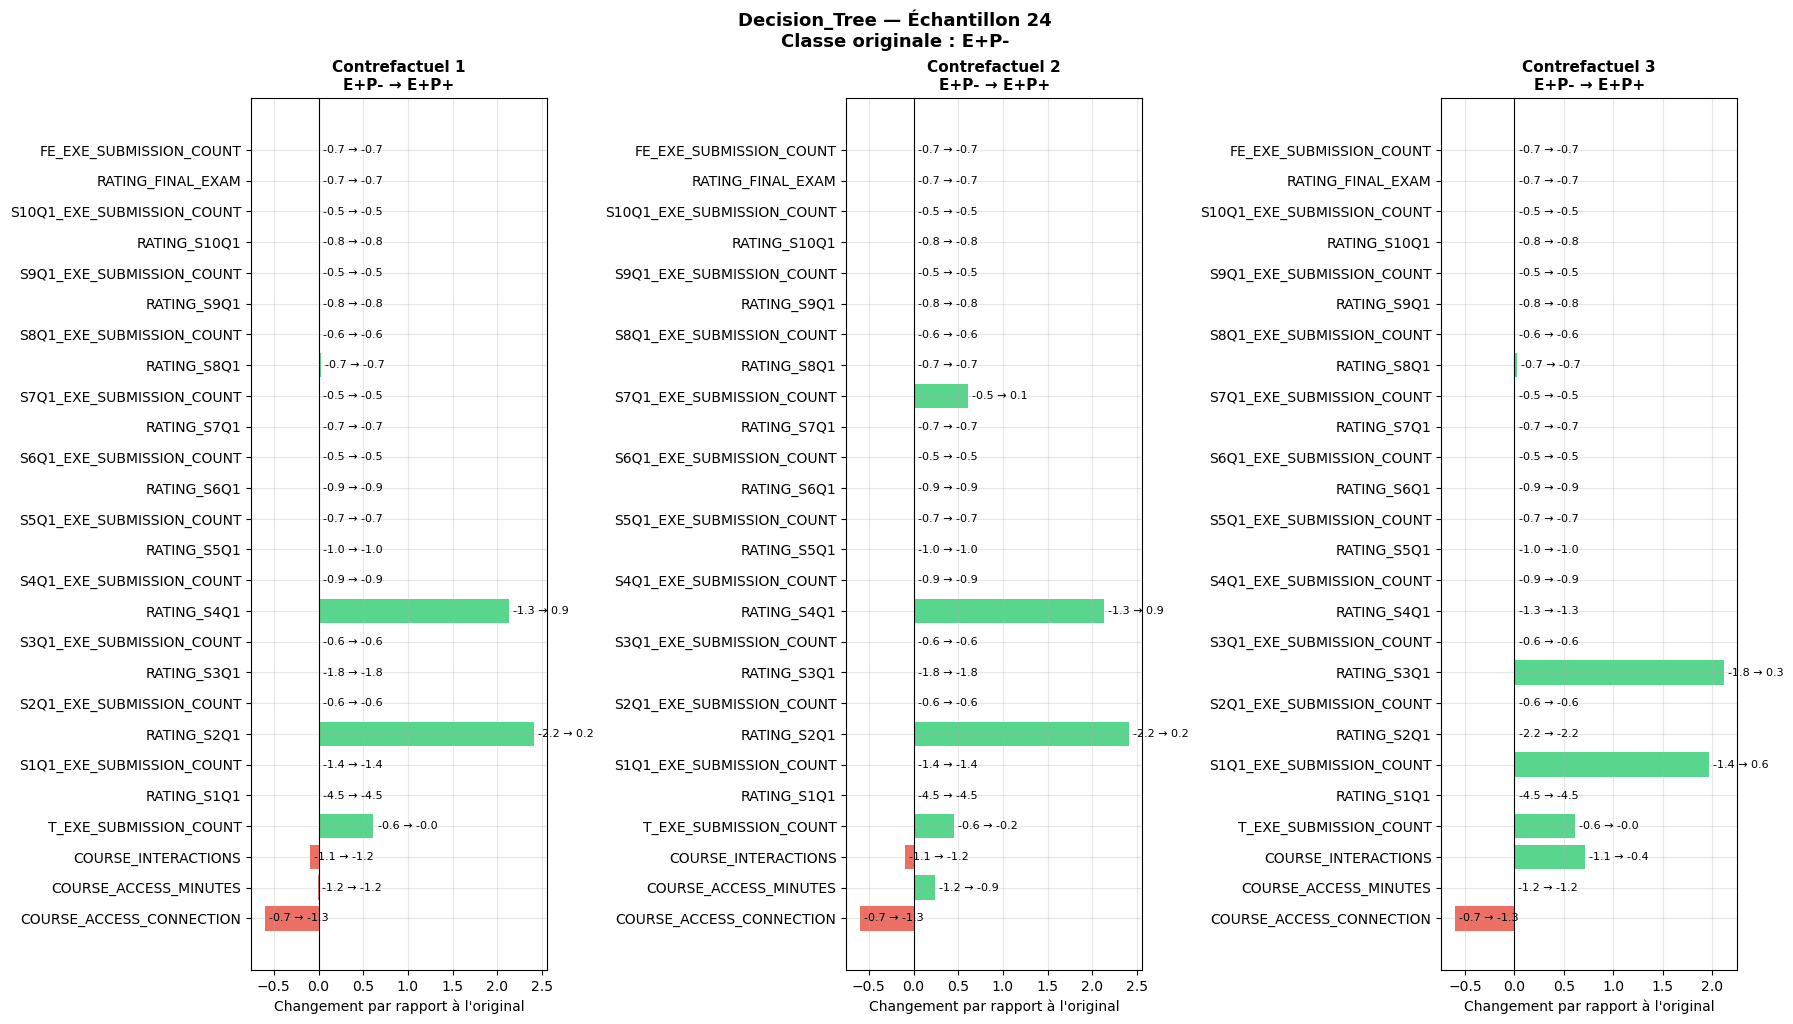


   Classe : E-P+

   Échantillon 12 — Classe originale : E-P+
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION        1.61        0.61        0.81       -0.09
COURSE_ACCESS_MINUTES           0.34       -1.04       -0.19       -0.94
COURSE_INTERACTIONS             0.68       -0.63       -0.46       -0.80
T_EXE_SUBMISSION_COUNT         -0.23       -0.48       -0.56       -0.56
RATING_S1Q1                    -0.08       -0.08       -0.08       -0.08
S1Q1_EXE_SUBMISSION_COUNT      -0.87        0.11       -0.87       -0.87
RATING_S2Q1                     0.16        0.16       -0.14        0.76
S2Q1_EXE_SUBMISSION_COUNT      -0.30       -0.30       -0.30       -0.30
RATING_S3Q1                     0.56        0.56        0.42       -0.50
S3Q1_EXE_SUBMISSION_COUNT      -0.27       -0.27       -0.27       -0.27
RATING_S4Q1                     0.64       -1.24       -1.24       -1.24
S4Q1_EXE_

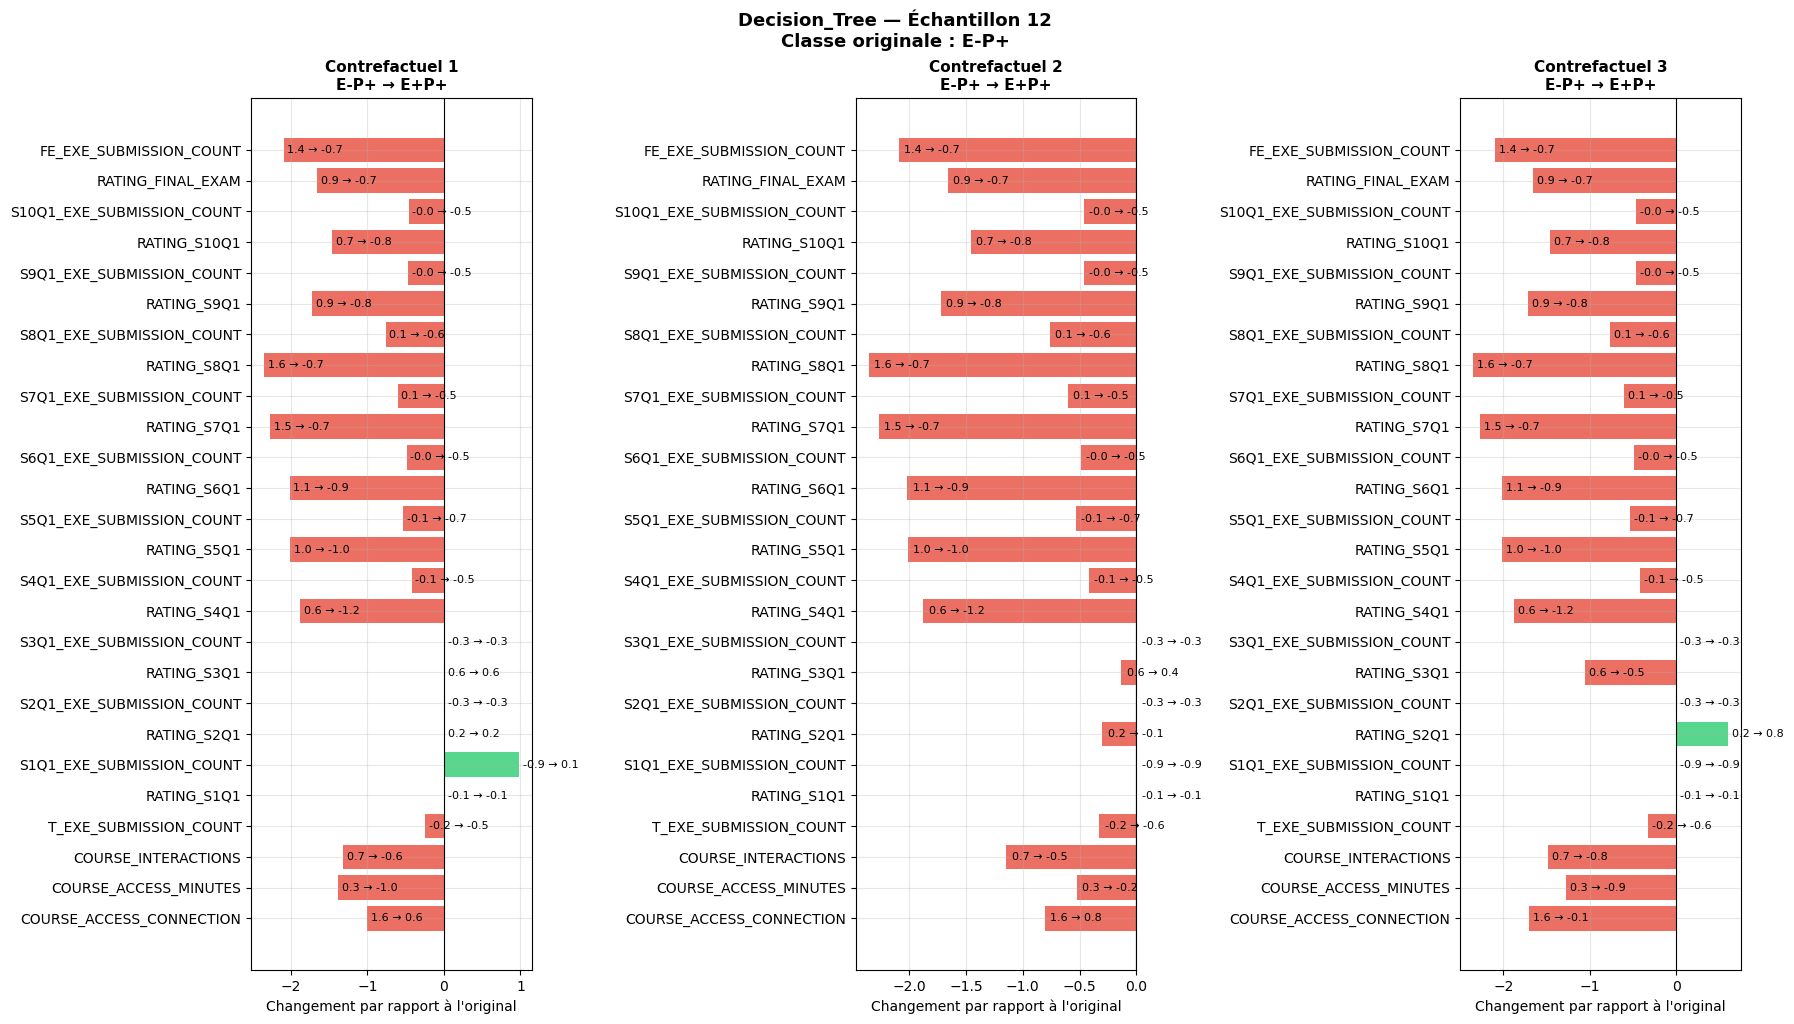


   Échantillon 0 — Classe originale : E-P+
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION        1.91       -0.74       -1.30       -0.80
COURSE_ACCESS_MINUTES           0.82       -1.17       -1.17       -1.17
COURSE_INTERACTIONS             0.78       -0.20       -1.20       -1.20
T_EXE_SUBMISSION_COUNT         -0.19       -0.14       -0.39       -0.39
RATING_S1Q1                     0.81        0.54       -4.49       -4.49
S1Q1_EXE_SUBMISSION_COUNT      -0.87       -1.36        0.60       -1.36
RATING_S2Q1                    -0.14       -2.25       -2.25        0.16
S2Q1_EXE_SUBMISSION_COUNT      -0.30       -0.30       -0.64       -0.64
RATING_S3Q1                     0.69        0.52       -1.82       -1.82
S3Q1_EXE_SUBMISSION_COUNT      -0.27       -0.59        0.04       -0.27
RATING_S4Q1                     0.87        0.64       -1.26       -1.26
S4Q1_EXE_SUBMISSION_COUNT   

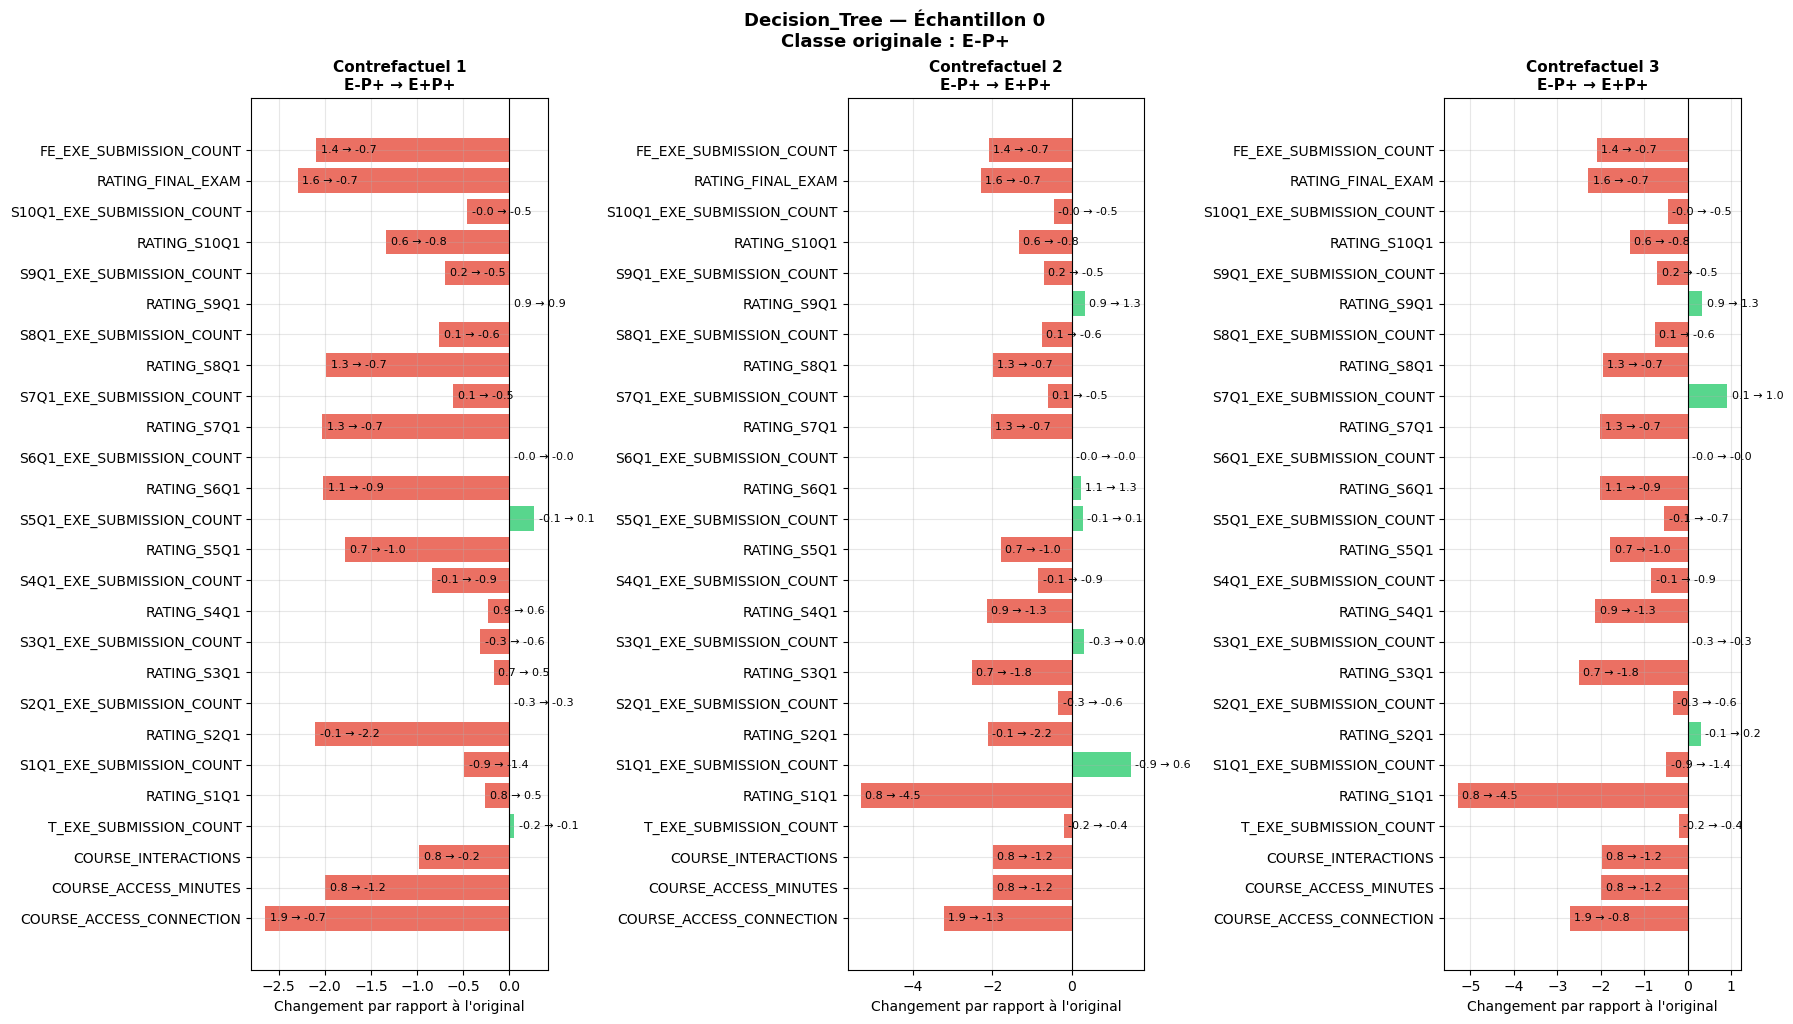


   Classe : E-P-

   Échantillon 7 — Classe originale : E-P-
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION       -0.90        0.81       -0.09        0.61
COURSE_ACCESS_MINUTES          -1.00       -0.19       -0.94       -1.04
COURSE_INTERACTIONS            -1.05       -0.46       -0.80       -0.63
T_EXE_SUBMISSION_COUNT         -0.60       -0.56       -0.56       -0.48
RATING_S1Q1                    -0.08       -0.08       -0.08       -0.08
S1Q1_EXE_SUBMISSION_COUNT      -0.87       -0.87       -0.87        0.11
RATING_S2Q1                    -0.14       -0.14        0.76        0.16
S2Q1_EXE_SUBMISSION_COUNT      -0.30       -0.30       -0.30       -0.30
RATING_S3Q1                    -1.82        0.42       -0.50        0.56
S3Q1_EXE_SUBMISSION_COUNT      -0.59       -0.27       -0.27       -0.27
RATING_S4Q1                    -1.24       -1.24       -1.24       -1.24
S4Q1_EXE_S

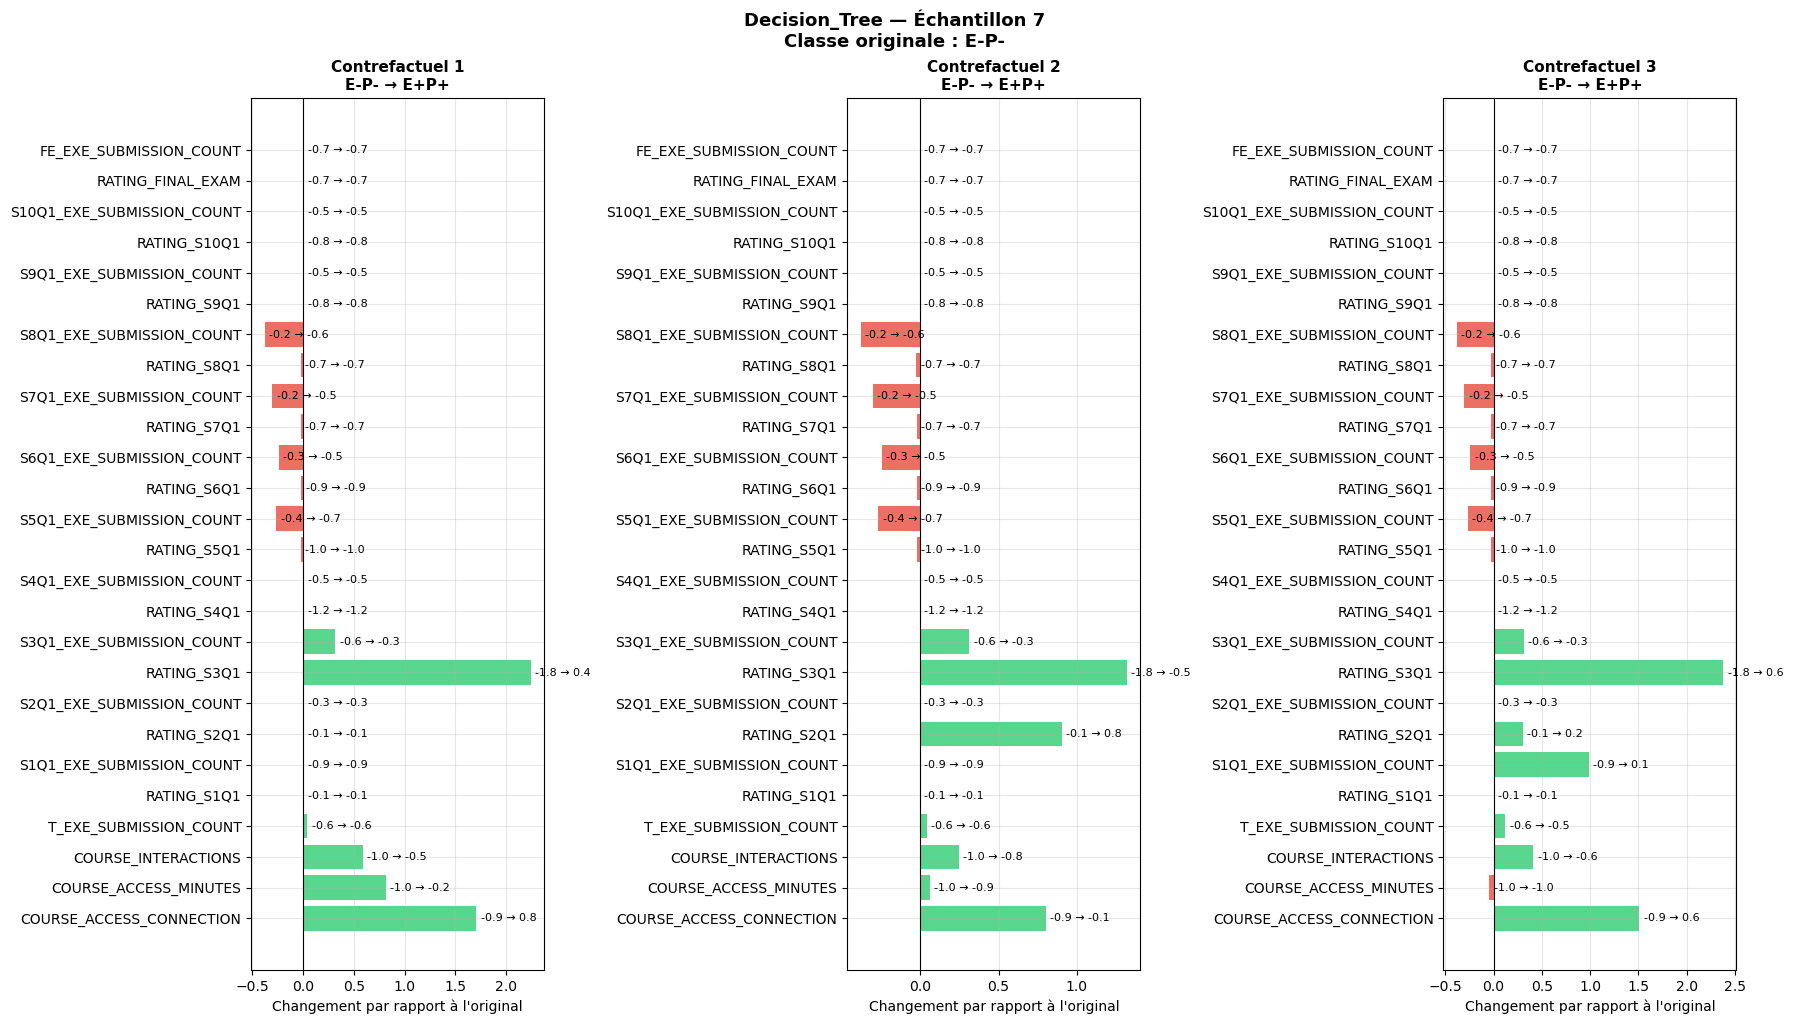


   Échantillon 18 — Classe originale : E-P-
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION       -1.20       -1.30       -1.30       -1.30
COURSE_ACCESS_MINUTES          -1.09       -1.17       -1.17       -1.17
COURSE_INTERACTIONS            -1.02       -1.20       -1.20       -1.20
T_EXE_SUBMISSION_COUNT         -0.60       -0.10       -0.14       -0.10
RATING_S1Q1                    -0.08        0.81       -4.49        0.81
S1Q1_EXE_SUBMISSION_COUNT      -0.87       -1.36       -1.36        0.63
RATING_S2Q1                    -2.25       -2.25        0.06       -2.25
S2Q1_EXE_SUBMISSION_COUNT      -0.64       -0.64       -0.64       -0.64
RATING_S3Q1                    -1.82        0.49       -1.82       -1.82
S3Q1_EXE_SUBMISSION_COUNT      -0.59       -0.59       -0.59        0.04
RATING_S4Q1                    -1.24        0.54       -1.26        0.54
S4Q1_EXE_SUBMISSION_COUNT  

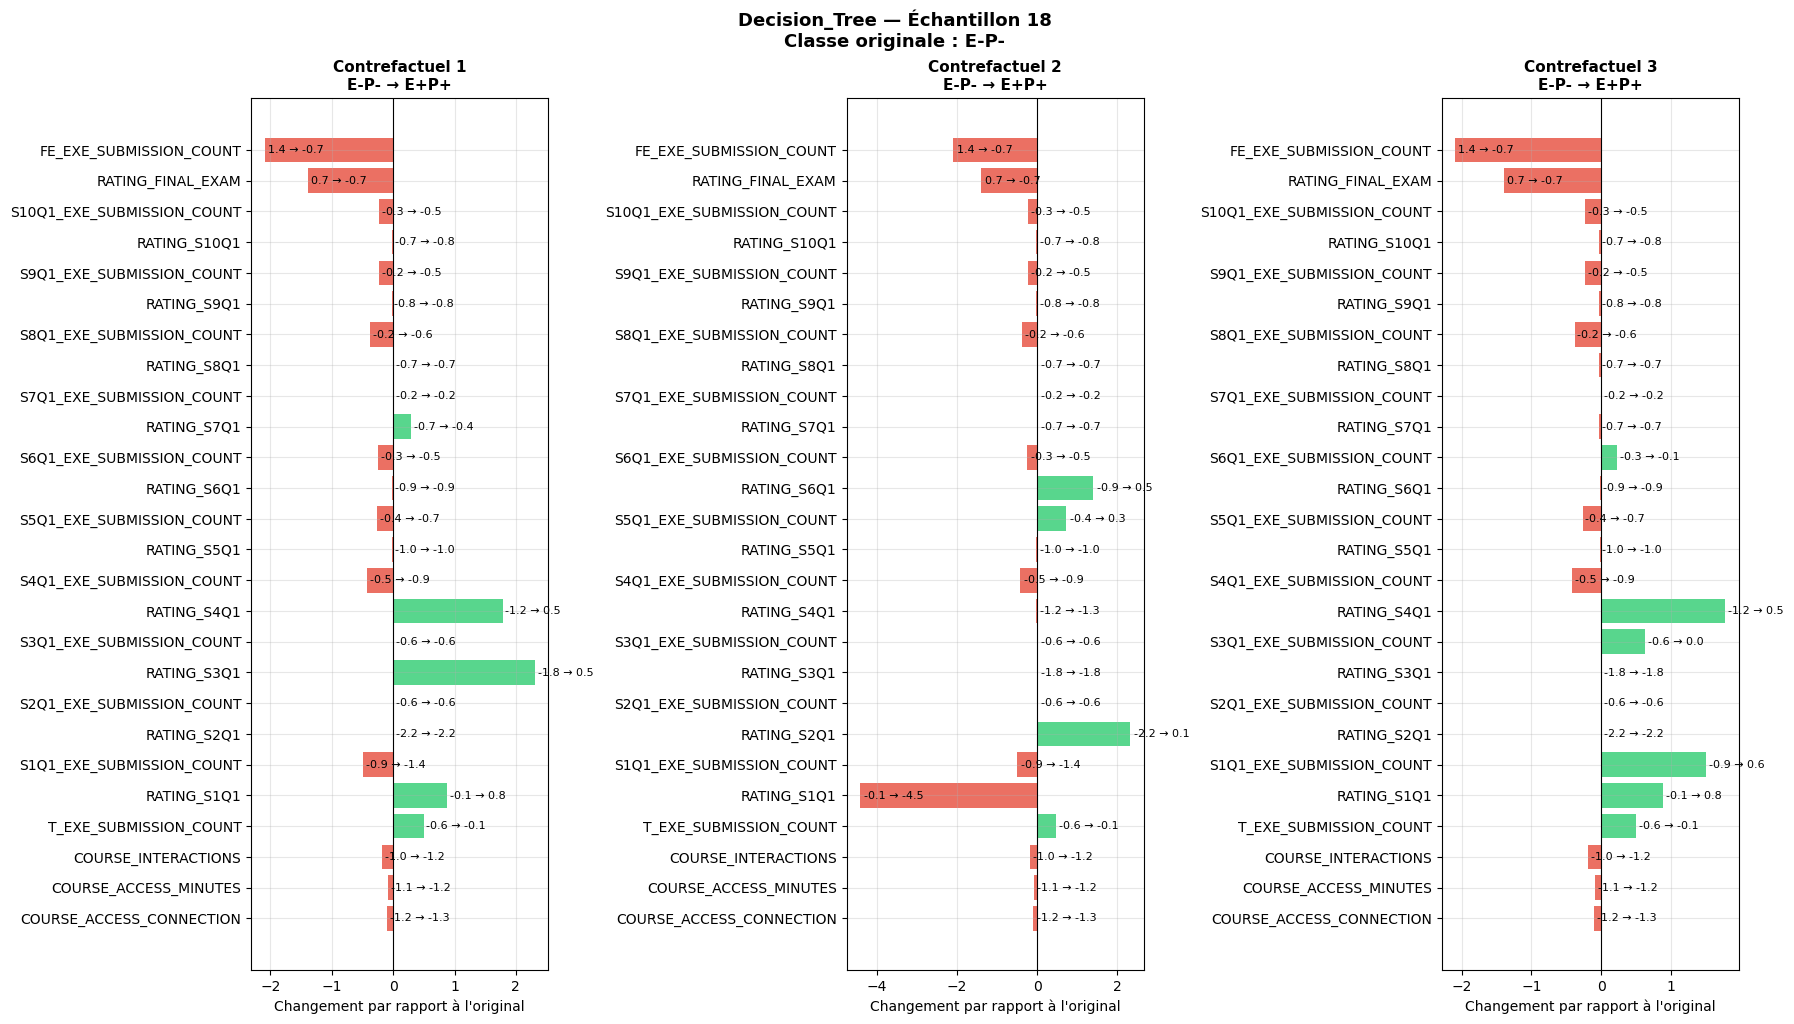


 VISUALISATION DiCE — Random_Forest

   Classe : E+P-

   Échantillon 14 — Classe originale : E+P-
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION       -1.00       -0.80       -1.00       -0.60
COURSE_ACCESS_MINUTES          -0.15       -0.68       -0.44       -0.28
COURSE_INTERACTIONS            -0.46       -0.40       -0.20       -0.48
T_EXE_SUBMISSION_COUNT         -0.19       -0.19       -0.27       -0.39
RATING_S1Q1                    -0.08        0.81        0.54        0.81
S1Q1_EXE_SUBMISSION_COUNT       1.09        0.11        0.41       -0.87
RATING_S2Q1                     0.46        0.16       -0.14        0.16
S2Q1_EXE_SUBMISSION_COUNT       0.04        0.39       -0.64       -0.30
RATING_S3Q1                     0.82        0.56       -1.82        0.56
S3Q1_EXE_SUBMISSION_COUNT       0.67        0.04       -0.27        0.04
RATING_S4Q1                     0.64        0

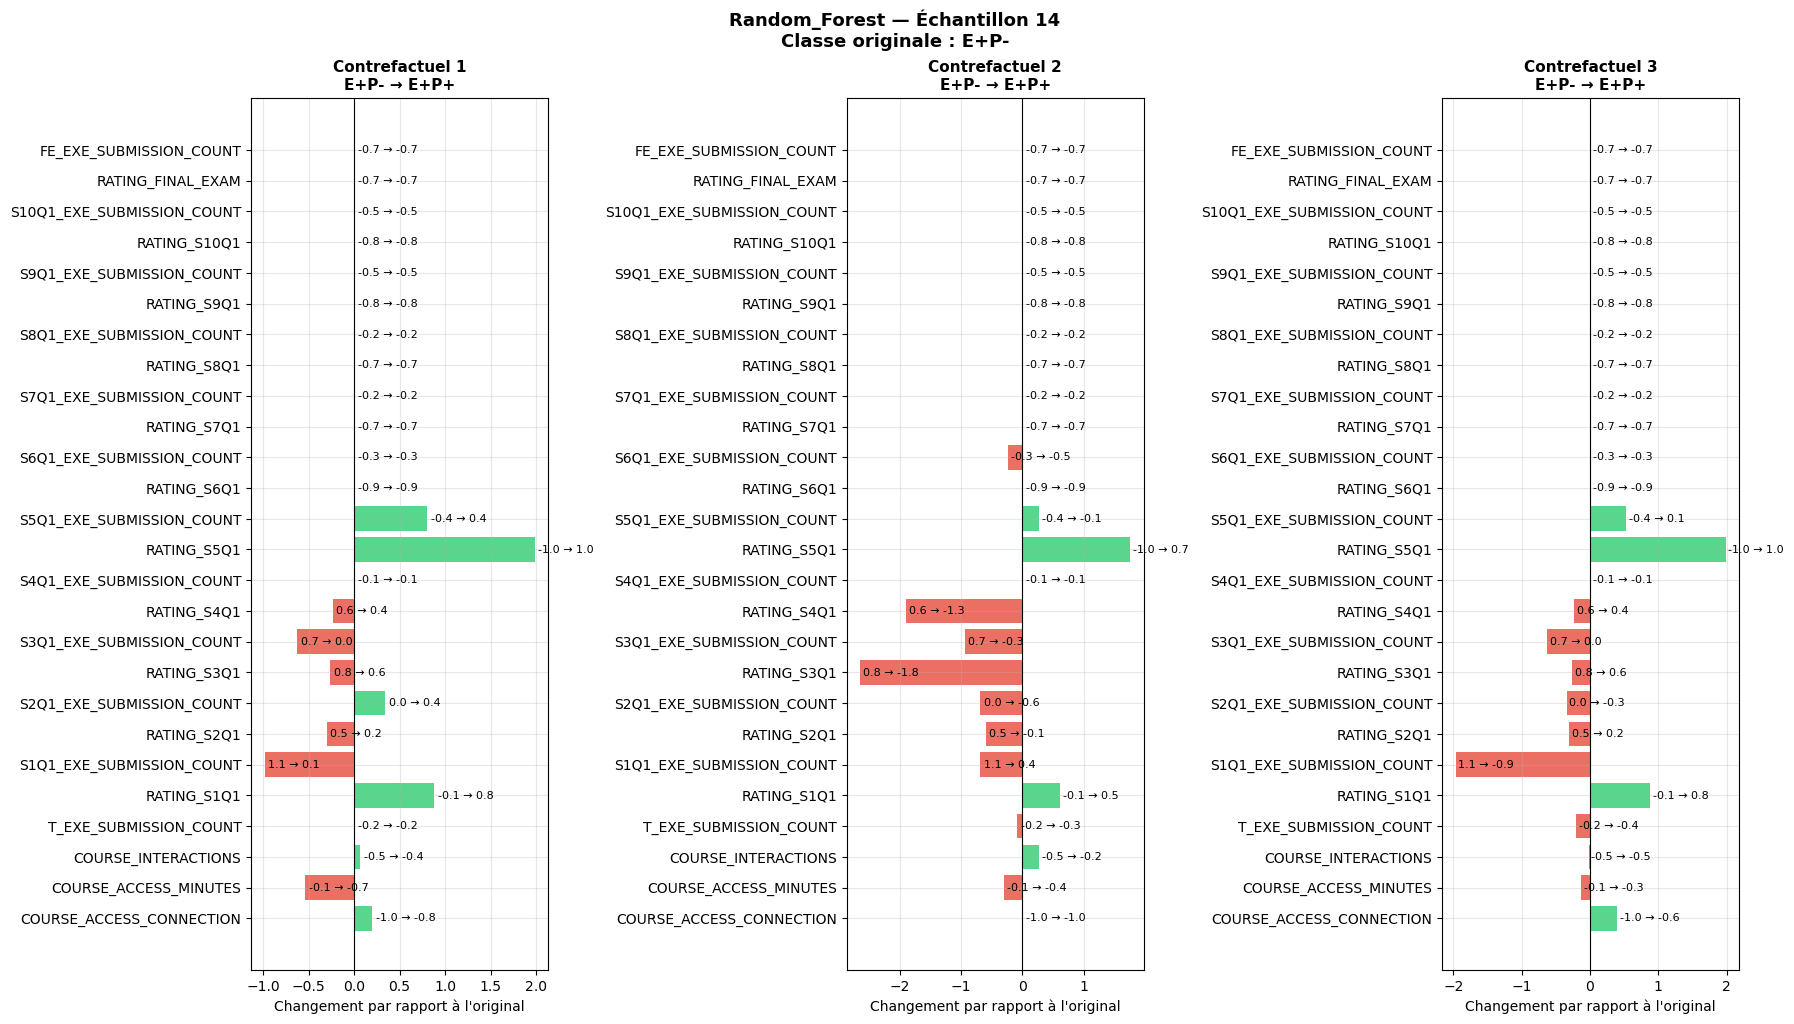


   Classe : E-P-

   Échantillon 22 — Classe originale : E-P-
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION       -0.80       -0.60       -0.74        0.61
COURSE_ACCESS_MINUTES          -0.75       -0.28       -0.44       -1.04
COURSE_INTERACTIONS            -0.42       -0.48       -0.35       -0.63
T_EXE_SUBMISSION_COUNT         -0.11       -0.39       -0.14       -0.48
RATING_S1Q1                    -0.08        0.81        0.54       -0.08
S1Q1_EXE_SUBMISSION_COUNT       1.09        0.63        0.41        0.11
RATING_S2Q1                     0.16       -0.00        0.06        0.16
S2Q1_EXE_SUBMISSION_COUNT       0.39       -0.30        0.39       -0.30
RATING_S3Q1                     0.03        0.56        0.52        0.56
S3Q1_EXE_SUBMISSION_COUNT       0.35       -0.12       -0.06       -0.27
RATING_S4Q1                     0.40        0.40        0.54       -1.24
S4Q1_EXE_

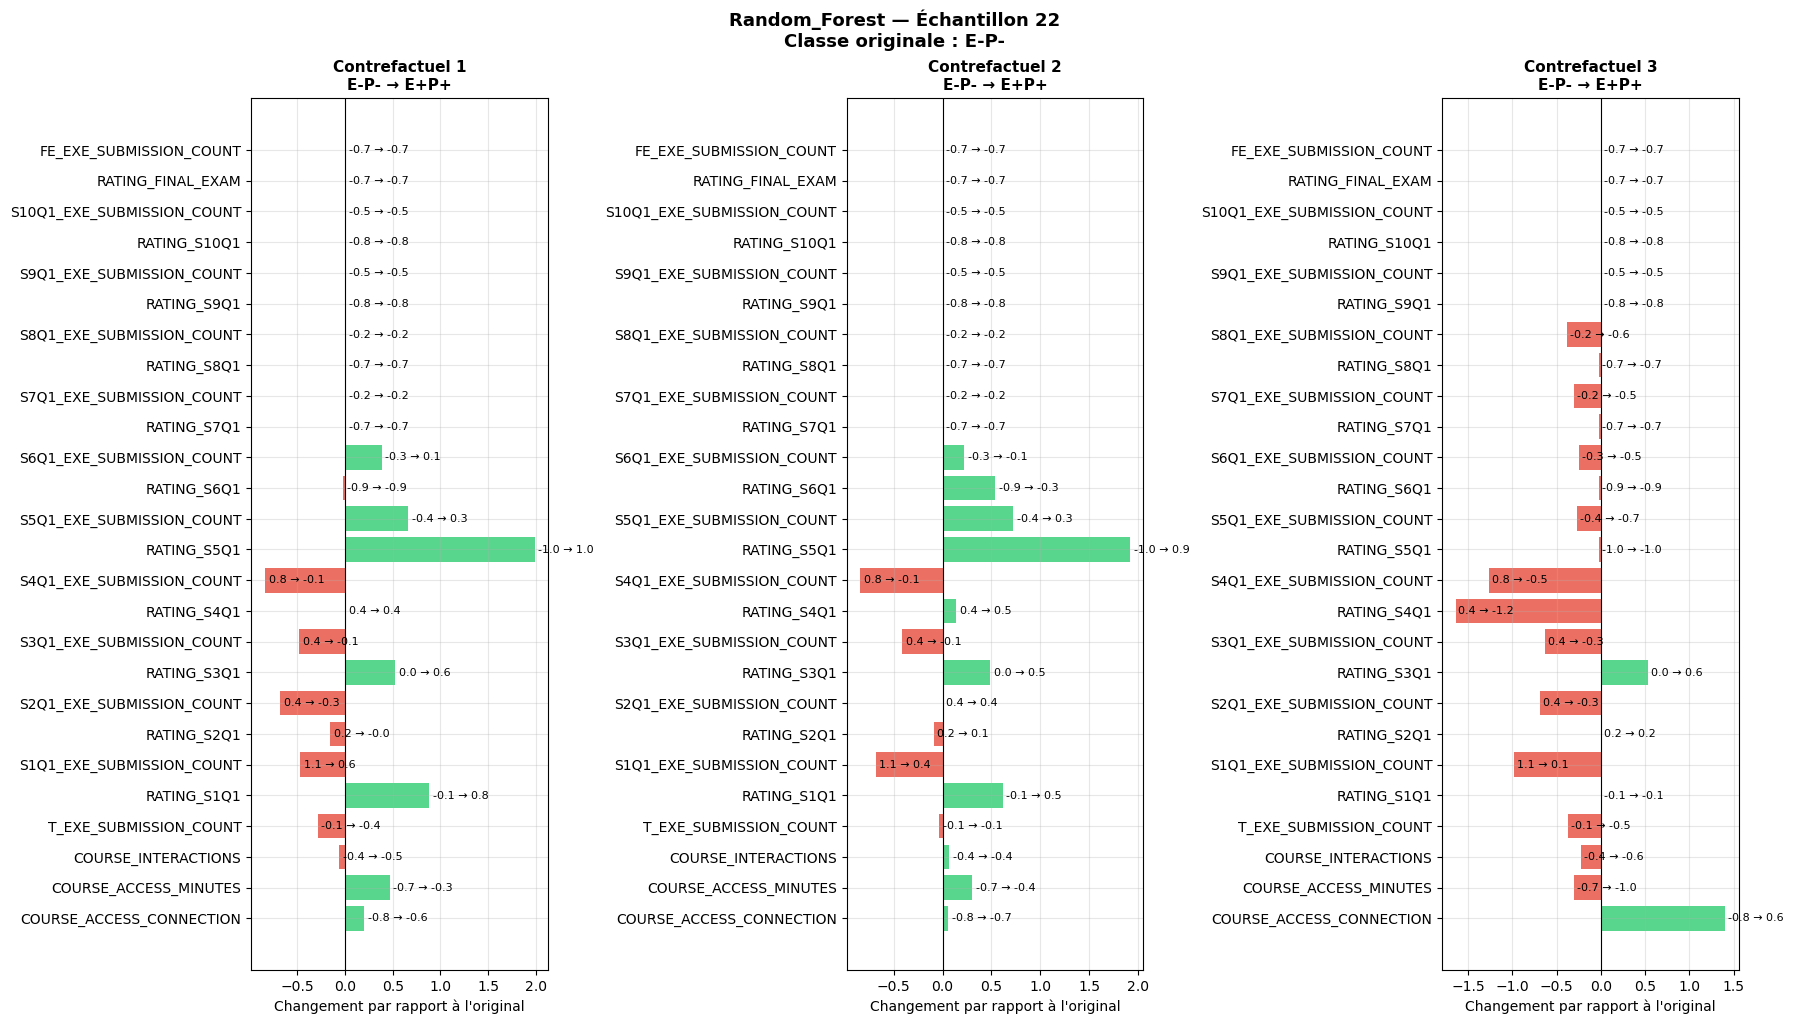


 VISUALISATION DiCE — XGBoost

   Classe : E+P-

   Échantillon 14 — Classe originale : E+P-
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION       -1.00       -1.00       -1.00       -0.80
COURSE_ACCESS_MINUTES          -0.15        0.11        0.11        0.83
COURSE_INTERACTIONS            -0.46       -0.20        0.08       -0.40
T_EXE_SUBMISSION_COUNT         -0.19       -0.27       -0.27       -0.19
RATING_S1Q1                    -0.08       -0.08       -0.08       -0.08
S1Q1_EXE_SUBMISSION_COUNT       1.09        1.09        1.09        0.60
RATING_S2Q1                     0.46       -0.14       -2.25        0.46
S2Q1_EXE_SUBMISSION_COUNT       0.04       -0.30       -0.30       -0.30
RATING_S3Q1                     0.82        0.69        0.56        0.69
S3Q1_EXE_SUBMISSION_COUNT       0.67       -0.27       -0.27       -0.27
RATING_S4Q1                     0.64        0.64   

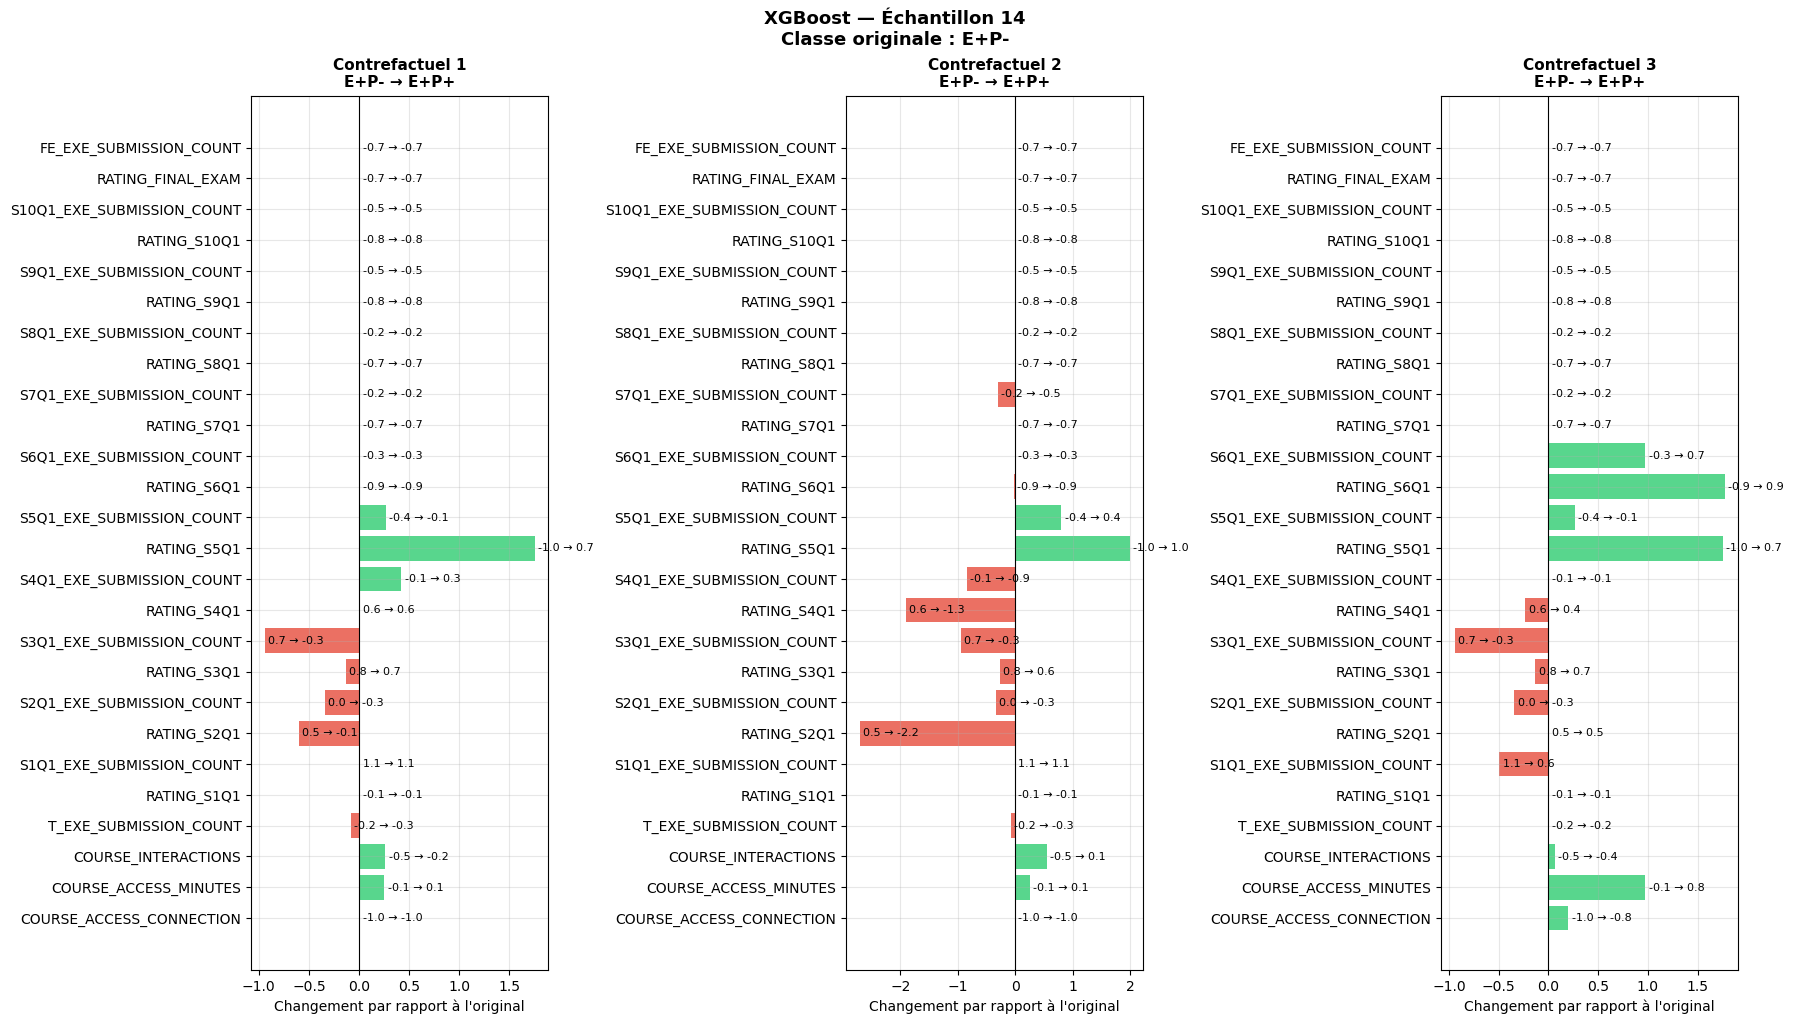


   Échantillon 24 — Classe originale : E+P-
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)
COURSE_ACCESS_CONNECTION       -0.70        0.11        0.21
COURSE_ACCESS_MINUTES          -1.16        0.29        0.01
COURSE_INTERACTIONS            -1.11       -0.08        0.13
T_EXE_SUBMISSION_COUNT         -0.64       -0.15       -0.27
RATING_S1Q1                    -4.49        0.28        0.28
S1Q1_EXE_SUBMISSION_COUNT      -1.36        1.09       -0.38
RATING_S2Q1                    -2.25        0.46        0.76
S2Q1_EXE_SUBMISSION_COUNT      -0.64       -0.30       -0.30
RATING_S3Q1                    -1.82        0.56        0.69
S3Q1_EXE_SUBMISSION_COUNT      -0.59        1.30        0.35
RATING_S4Q1                    -1.26        0.87        0.87
S4Q1_EXE_SUBMISSION_COUNT      -0.93       -0.09       -0.09
RATING_S5Q1                    -1.03        0.68        0.81
S5Q1_EXE_SUBMISSION_COUNT      -0.66       -0.13 

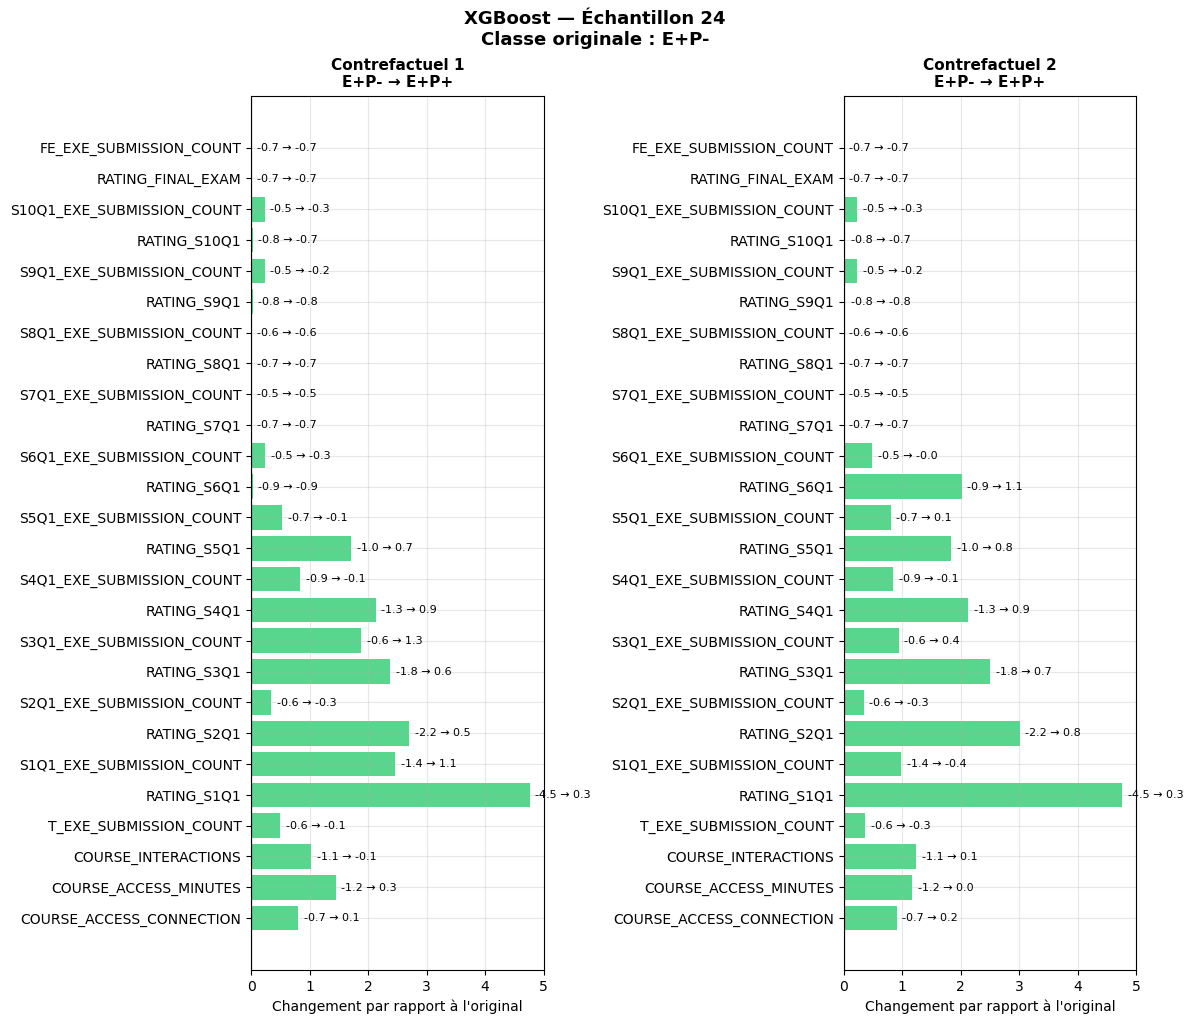


   Classe : E-P+

   Échantillon 1 — Classe originale : E-P+
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION        0.41        2.92        3.12        2.82
COURSE_ACCESS_MINUTES          -0.18        0.83        1.60        1.01
COURSE_INTERACTIONS             0.44        1.23        1.64        2.69
T_EXE_SUBMISSION_COUNT          0.26       -0.07        0.26        2.39
RATING_S1Q1                     0.81        0.81       -0.08        0.81
S1Q1_EXE_SUBMISSION_COUNT      -0.87       -0.87        0.11        1.59
RATING_S2Q1                    -0.14        0.76        0.76        0.76
S2Q1_EXE_SUBMISSION_COUNT      -0.30        0.04        0.04        3.80
RATING_S3Q1                     0.16        0.82        0.03        0.82
S3Q1_EXE_SUBMISSION_COUNT       0.67       -0.27       -0.27        0.67
RATING_S4Q1                     0.87        0.87        0.64        0.87
S4Q1_EXE_S

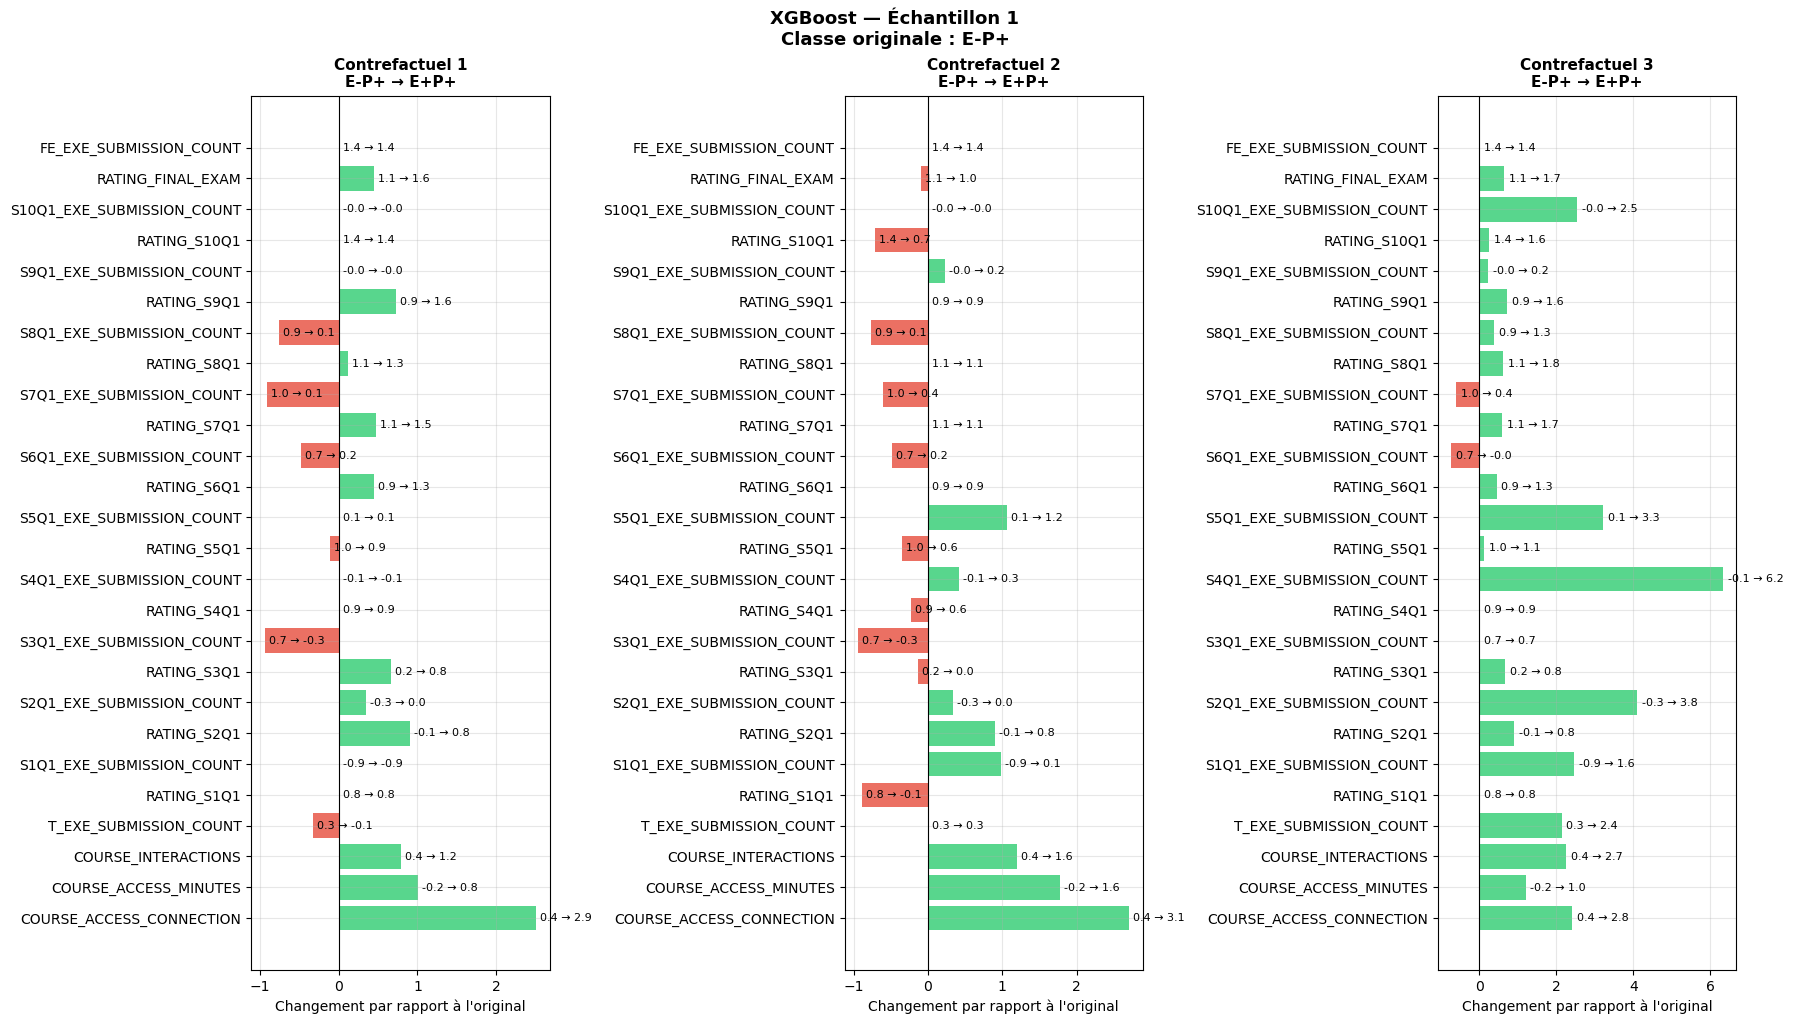


   Classe : E-P-

   Échantillon 7 — Classe originale : E-P-
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION       -0.90        0.11        0.21        0.31
COURSE_ACCESS_MINUTES          -1.00        0.29        0.01        0.66
COURSE_INTERACTIONS            -1.05       -0.08        0.13        0.96
T_EXE_SUBMISSION_COUNT         -0.60       -0.15       -0.27       -0.27
RATING_S1Q1                    -0.08        0.28        0.28       -0.78
S1Q1_EXE_SUBMISSION_COUNT      -0.87        1.09       -0.38       -0.38
RATING_S2Q1                    -0.14        0.46        0.76        0.46
S2Q1_EXE_SUBMISSION_COUNT      -0.30       -0.30       -0.30       -0.30
RATING_S3Q1                    -1.82        0.56        0.69        0.42
S3Q1_EXE_SUBMISSION_COUNT      -0.59        1.30        0.35       -0.27
RATING_S4Q1                    -1.24        0.87        0.87        1.10
S4Q1_EXE_S

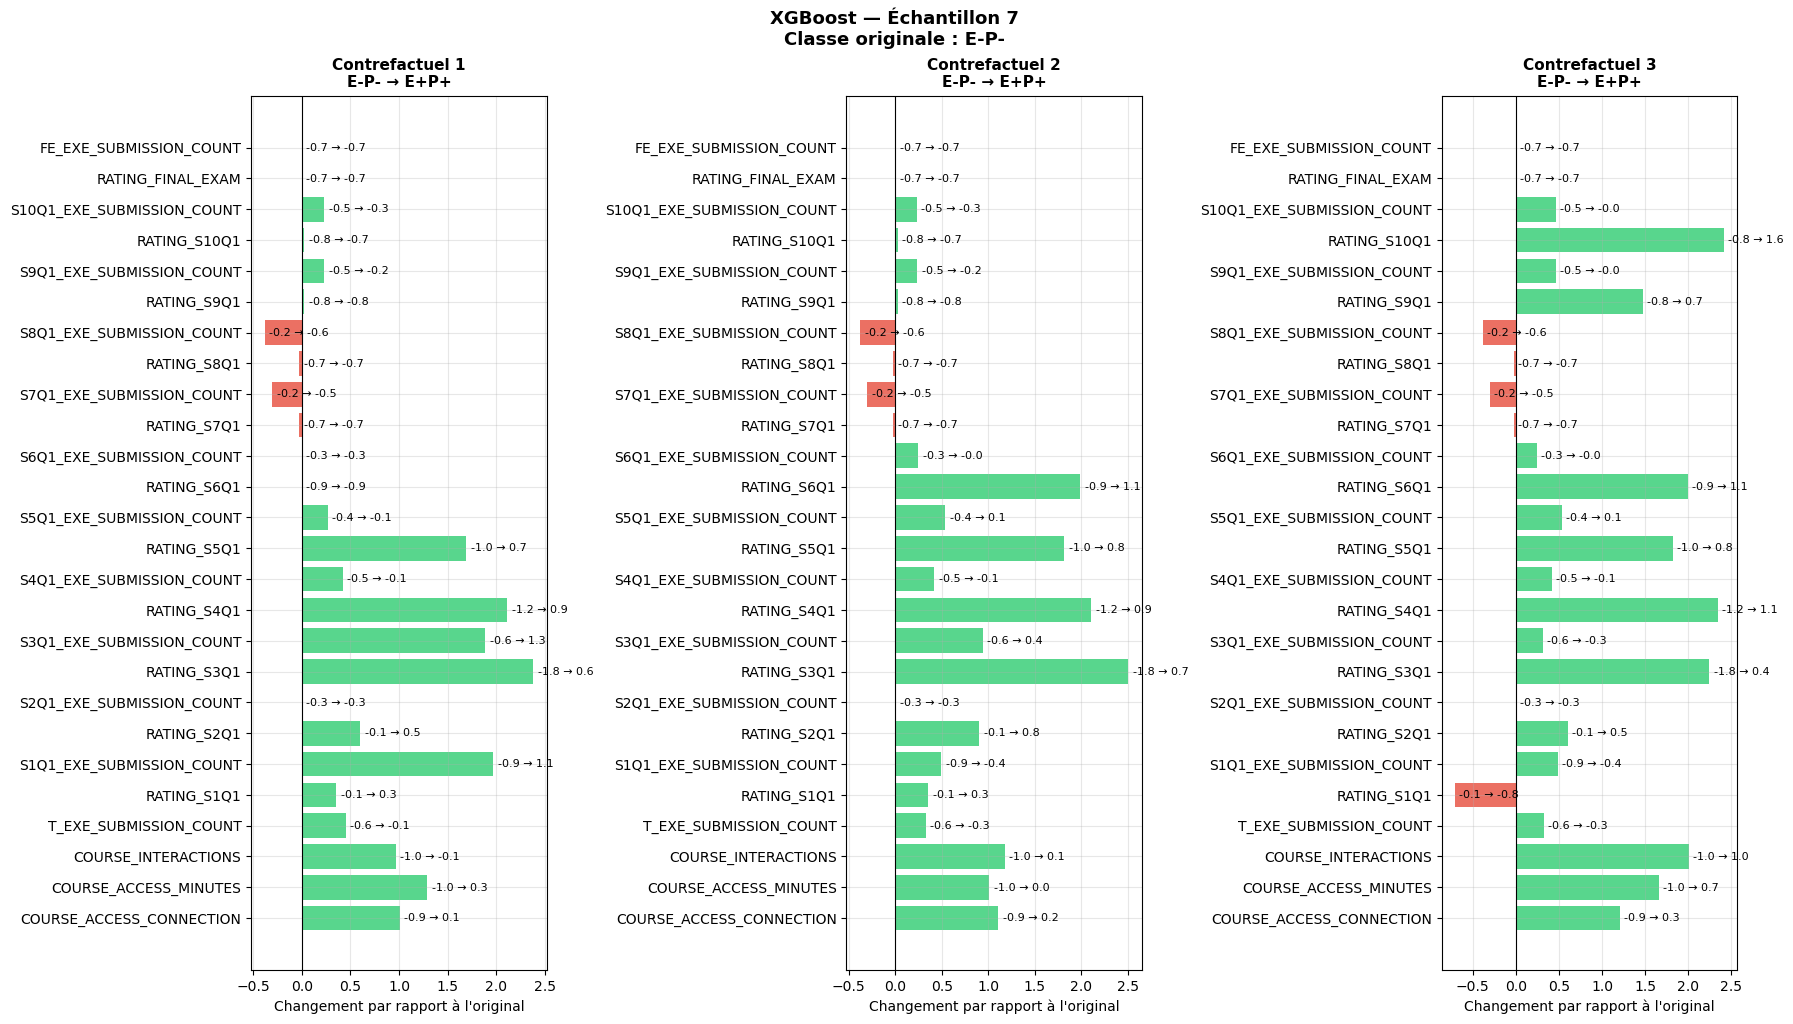


   Échantillon 18 — Classe originale : E-P-
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION       -1.20        0.11        0.21        3.12
COURSE_ACCESS_MINUTES          -1.09        0.29        0.01        1.60
COURSE_INTERACTIONS            -1.02       -0.08        0.13        1.64
T_EXE_SUBMISSION_COUNT         -0.60       -0.15       -0.27        0.26
RATING_S1Q1                    -0.08        0.28        0.28       -0.08
S1Q1_EXE_SUBMISSION_COUNT      -0.87        1.09       -0.38        0.11
RATING_S2Q1                    -2.25        0.46        0.76        0.76
S2Q1_EXE_SUBMISSION_COUNT      -0.64       -0.30       -0.30        0.04
RATING_S3Q1                    -1.82        0.56        0.69        0.03
S3Q1_EXE_SUBMISSION_COUNT      -0.59        1.30        0.35       -0.27
RATING_S4Q1                    -1.24        0.87        0.87        0.64
S4Q1_EXE_SUBMISSION_COUNT  

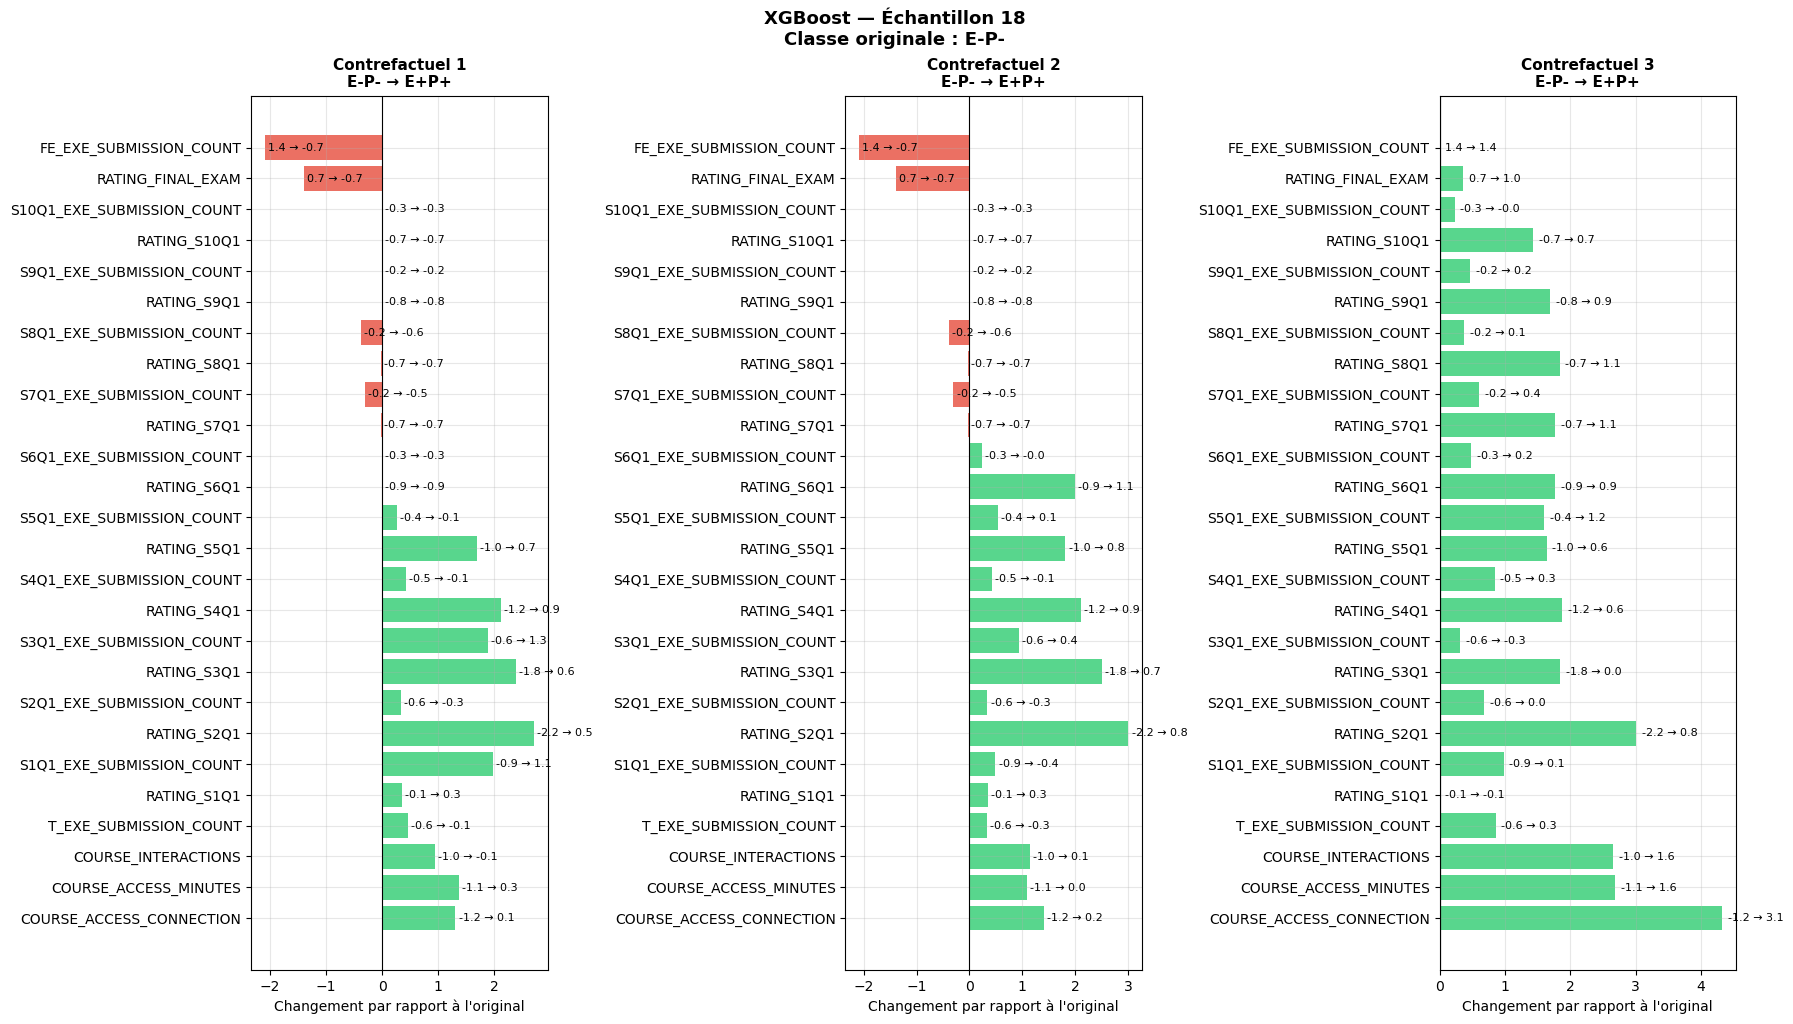


   Échantillon 22 — Classe originale : E-P-
   Features modifiées : 26

   Tableau comparatif :
                            Original  CF1 (E+P+)  CF2 (E+P+)  CF3 (E+P+)
COURSE_ACCESS_CONNECTION       -0.80       -1.00       -0.80       -1.30
COURSE_ACCESS_MINUTES          -0.75        0.11       -1.17       -1.17
COURSE_INTERACTIONS            -0.42       -0.20       -0.40       -0.25
T_EXE_SUBMISSION_COUNT         -0.11       -0.27       -0.19       -0.02
RATING_S1Q1                    -0.08       -0.08        0.81        0.81
S1Q1_EXE_SUBMISSION_COUNT       1.09        1.09        0.41       -0.38
RATING_S2Q1                     0.16       -0.14        0.16       -2.25
S2Q1_EXE_SUBMISSION_COUNT       0.39       -0.30       -0.64        0.39
RATING_S3Q1                     0.03        0.69       -1.82       -1.82
S3Q1_EXE_SUBMISSION_COUNT       0.35       -0.27       -0.59       -0.12
RATING_S4Q1                     0.40        0.64       -1.26       -1.26
S4Q1_EXE_SUBMISSION_COUNT  

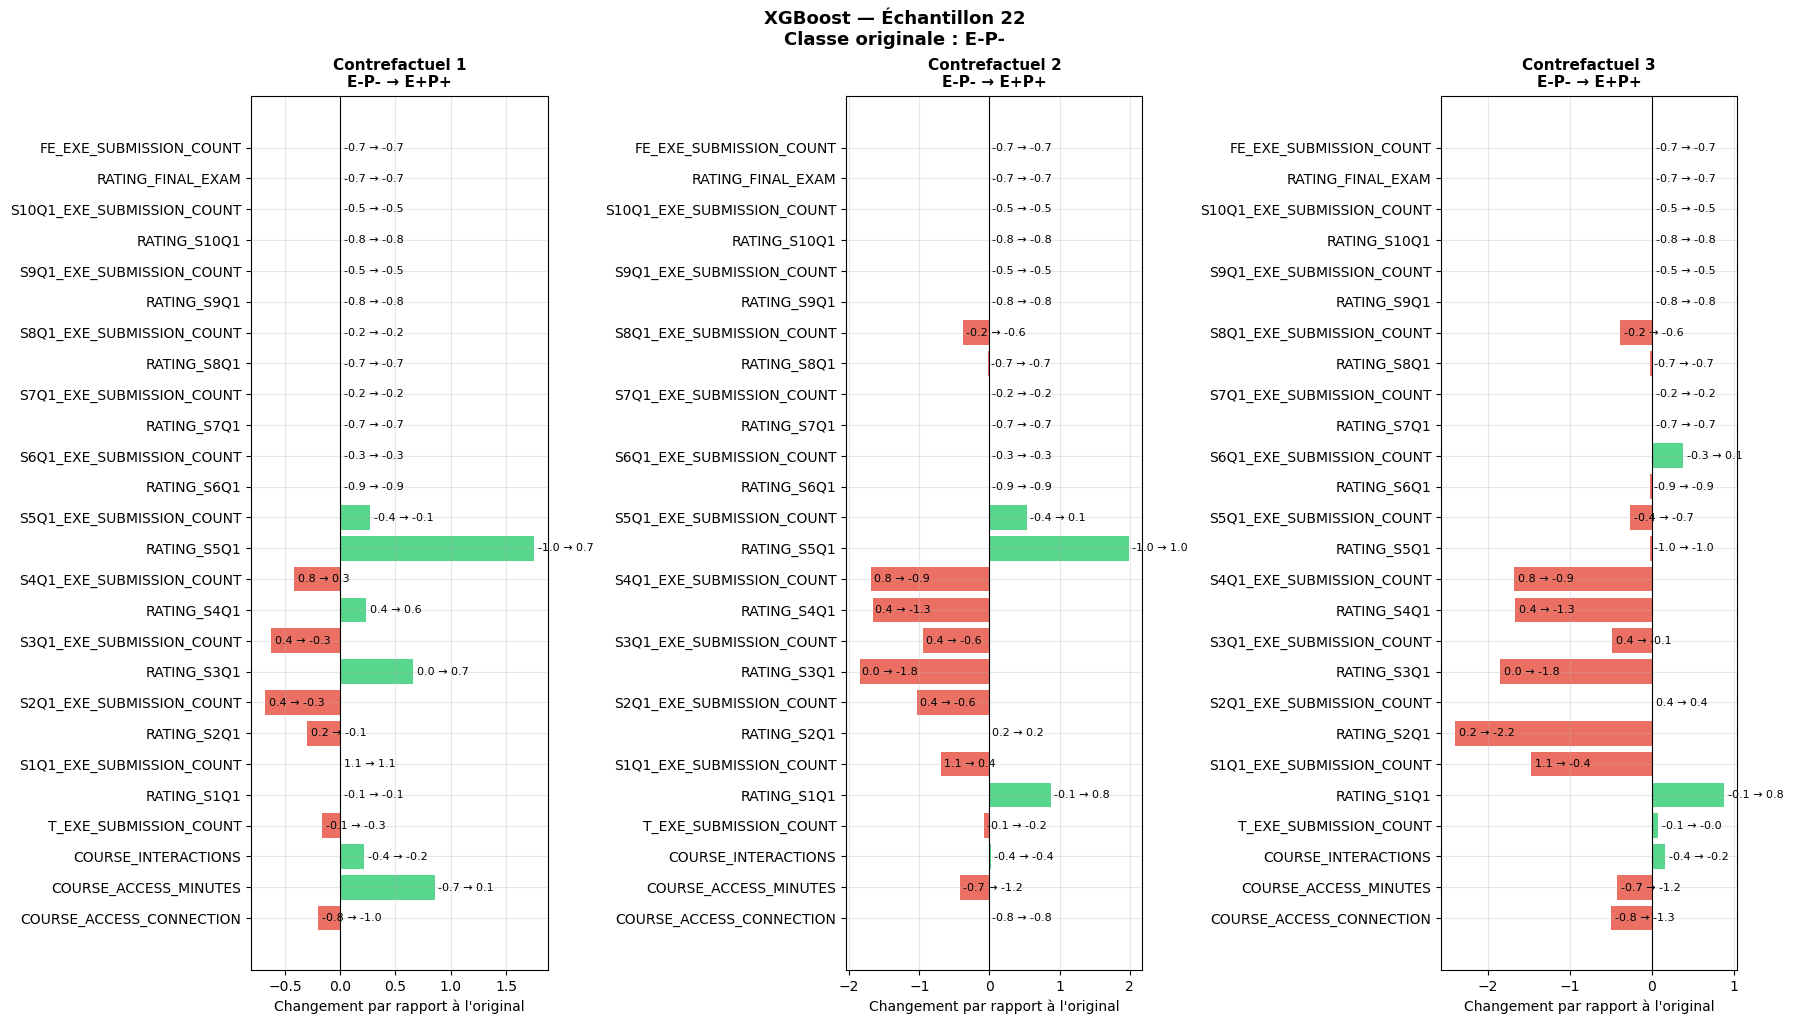


 RÉSUMÉ DES CONTREFACTUELS DiCE

 DECISION TREE
------------------------------------------------------------
   Total échantillons expliqués : 6

   Classe E+P+ :

   Classe E+P- :
      Échantillon 14 (E+P-) → ['E+P+', 'E+P+', 'E+P+']
      Échantillon 24 (E+P-) → ['E+P+', 'E+P+', 'E+P+']

   Classe E-P+ :
      Échantillon 12 (E-P+) → ['E+P+', 'E+P+', 'E+P+']
      Échantillon 0 (E-P+) → ['E+P+', 'E+P+', 'E+P+']

   Classe E-P- :
      Échantillon 7 (E-P-) → ['E+P+', 'E+P+', 'E+P+']
      Échantillon 18 (E-P-) → ['E+P+', 'E+P+', 'E+P+']

   Top 5 features les plus modifiées :
      COURSE_ACCESS_CONNECTION                 : modifiée 6 fois
      COURSE_ACCESS_MINUTES                    : modifiée 6 fois
      COURSE_INTERACTIONS                      : modifiée 6 fois
      T_EXE_SUBMISSION_COUNT                   : modifiée 6 fois
      RATING_S1Q1                              : modifiée 6 fois

 RANDOM FOREST
------------------------------------------------------------
   Total éch

In [19]:
dice_eval = DiCEEvaluator(evaluator)
dice_eval.run()

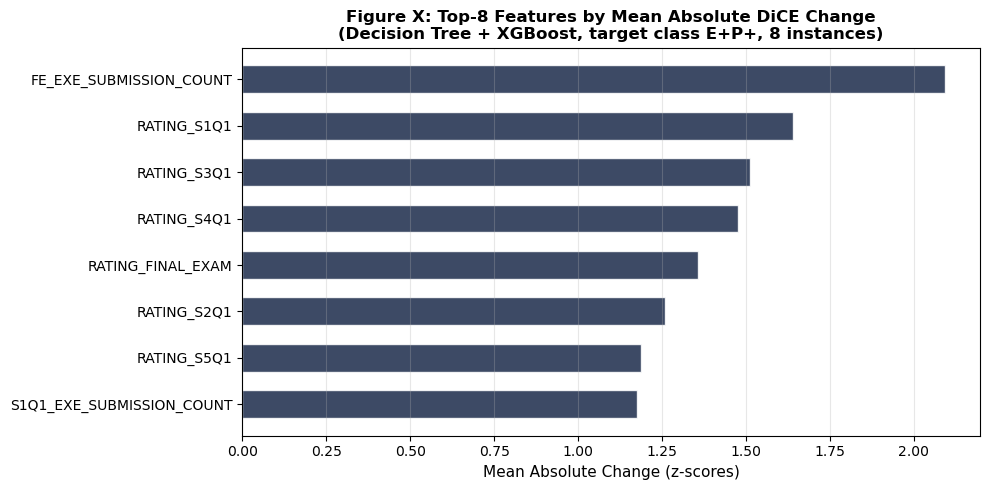

Saved: outputs/canva/figX_dice_top8.png


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os
os.makedirs('outputs/canva', exist_ok=True)

df = pd.read_csv('outputs/dice_explanations.csv')

# Top 8 features par abs_delta moyen
top8 = (df.groupby('feature')['abs_delta']
        .mean()
        .sort_values(ascending=True)
        .tail(8))

labels = [f[:30] + '...' if len(f) > 30 else f for f in top8.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top8)), top8.values,
        color='#1B2A4A', alpha=0.85, edgecolor='white', height=0.6)
ax.set_yticks(range(len(top8)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Mean Absolute Change (z-scores)', fontsize=11)
ax.set_title(
    'Figure X: Top-8 Features by Mean Absolute DiCE Change\n'
    '(Decision Tree + XGBoost, target class E+P+, 8 instances)',
    fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/canva/figX_dice_top8.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/canva/figX_dice_top8.png')